In [ ]:
!pip install pandas numpy seaborn matplotlib scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, ParameterGrid
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

#montando drive e lendo df
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Real estate.csv')

#visualizando nomes das colunas
print(df.columns)

#padronizando e encurtando os nomes
df.columns = ['ID', 'transaction_date', 'house_age', 'distance_MRT_Station', 'numbers_convenience', 'latitude', 'longitude', 'price_unit_area']
print(df.columns)

#visualizando dados
print(df)

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')
Index(['ID', 'transaction_date', 'house_age', 'distance_MRT_Station',
       'numbers_convenience', 'latitude', 'longitude', 'price_unit_area'],
      dtype='object')
      ID  transaction_date  house_age  distance_MRT_Station  \
0      1          2012.917       32.0              84.87882   
1      2          2012.917       19.5             306.59470   
2      3          2013.583       13.3             561.98450   
3      4          2013.500       13.3             561.98450   
4      5          2012.833        5.0             390.56840   
..   ...               ...        ...                   ...   
409  410          2013.000       13.7            4082.01500   
410  411          2012.667        5.6              90.45606   
411  412          2013.250      

In [ ]:
#Eliminando coluna do Id(não tem importancia)
df.drop(columns=['ID'], inplace=True)
print(df.columns)

#verificar dados faltantes
df.isnull().sum()

Index(['transaction_date', 'house_age', 'distance_MRT_Station',
       'numbers_convenience', 'latitude', 'longitude', 'price_unit_area'],
      dtype='object')


,0
transaction_date,0
house_age,0
distance_MRT_Station,0
numbers_convenience,0
latitude,0
longitude,0
price_unit_area,0


In [ ]:
#printando maximo e minimo da feature house_age para analise
maximo = df['house_age'].max()
minimo = df['house_age'].min()
print(f'Máximo: {maximo}, Mínimo: {minimo}')


Máximo: 43.8, Mínimo: 0.0


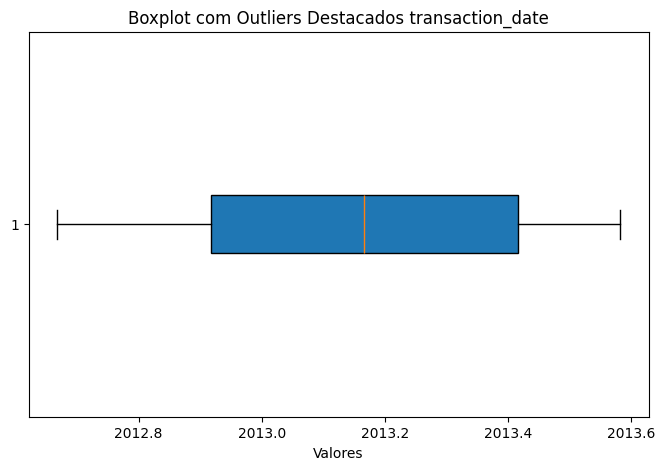

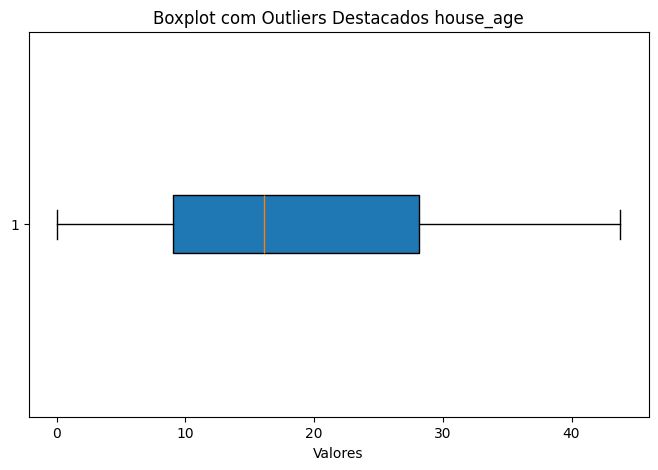

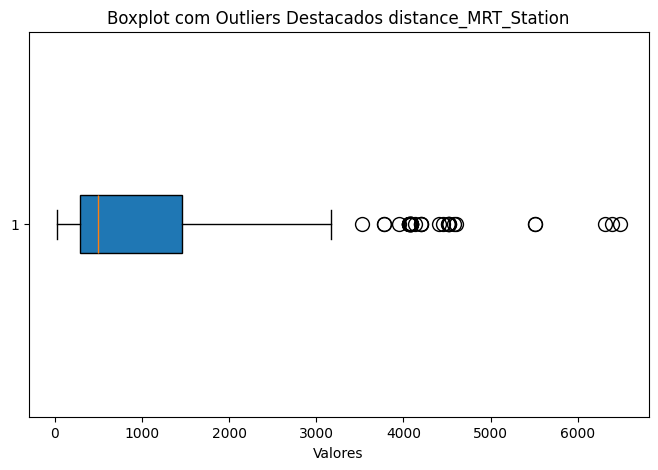

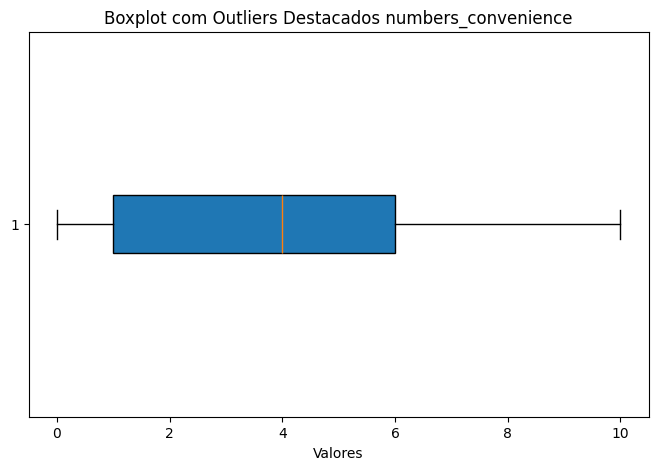

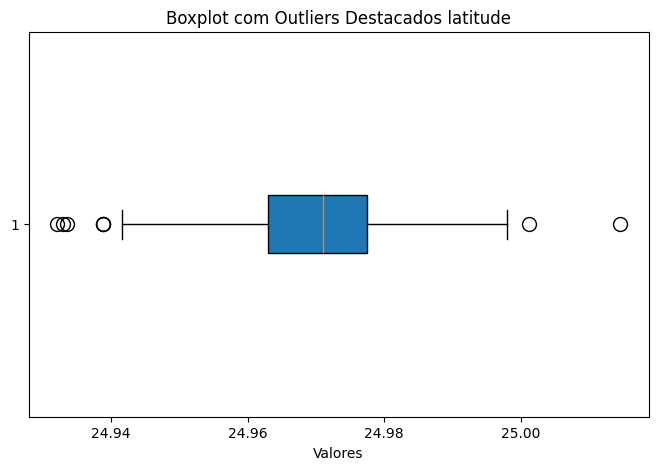

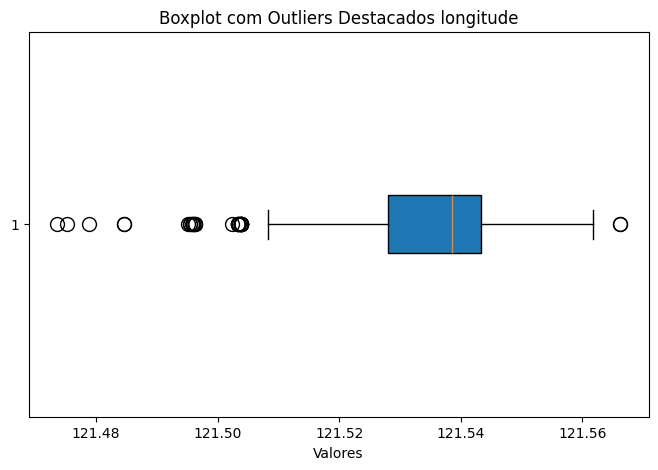

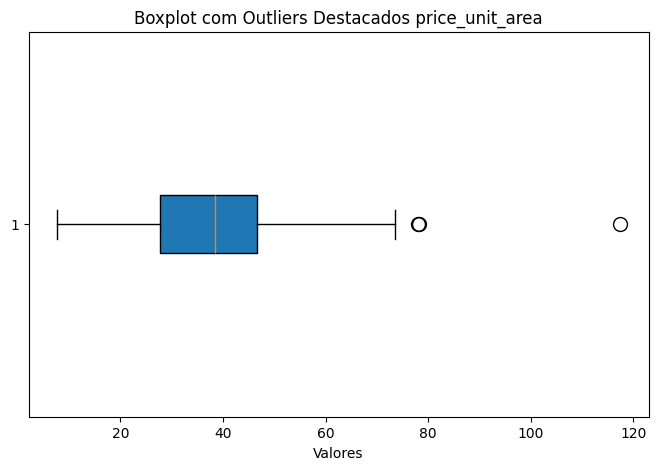

In [ ]:
#calculando os quartis e gerando bloxplots para visualização
for i in df.columns:
  Q1 = np.percentile(df[i], 25)
  Q2 = np.percentile(df[i], 50)
  Q3 = np.percentile(df[i], 75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  outliers = [x for x in df[i] if x < limite_inferior or x > limite_superior]

  plt.figure(figsize=(8, 5))
  plt.boxplot(df[i], vert=False, patch_artist=True, flierprops=dict(marker='o', color='red', markersize=10))
  plt.title("Boxplot com Outliers Destacados " + i)
  plt.xlabel("Valores")

  #percebe-se outliers no MRT_station, latitude, longitude, price unit area

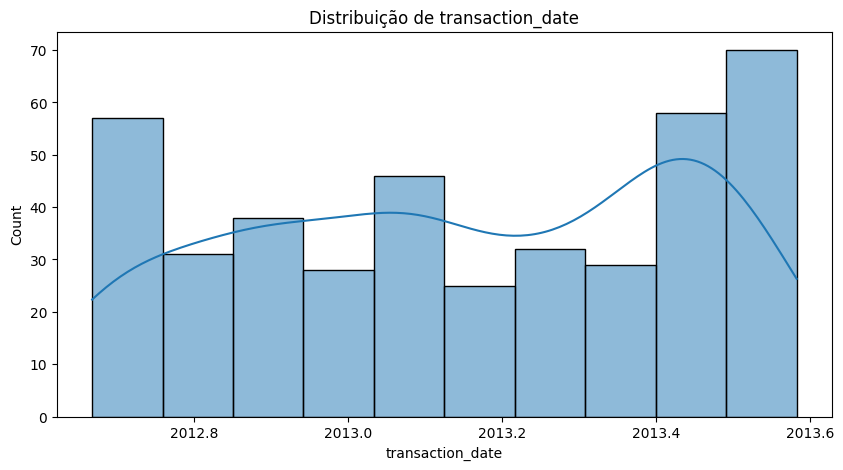

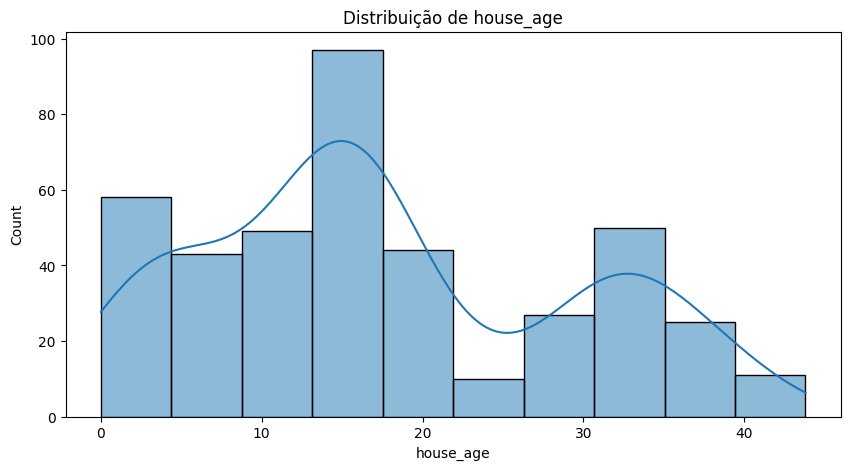

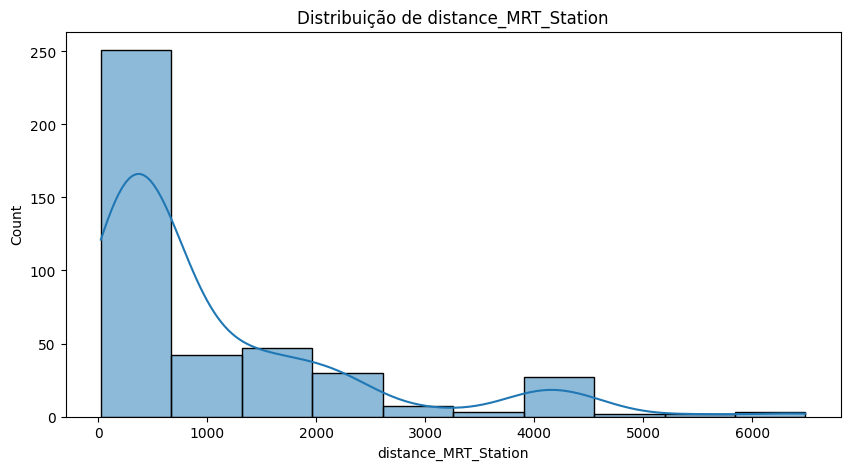

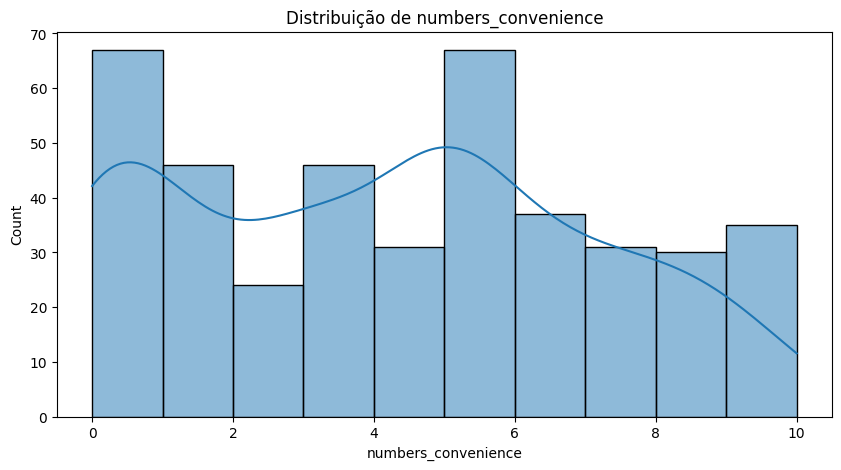

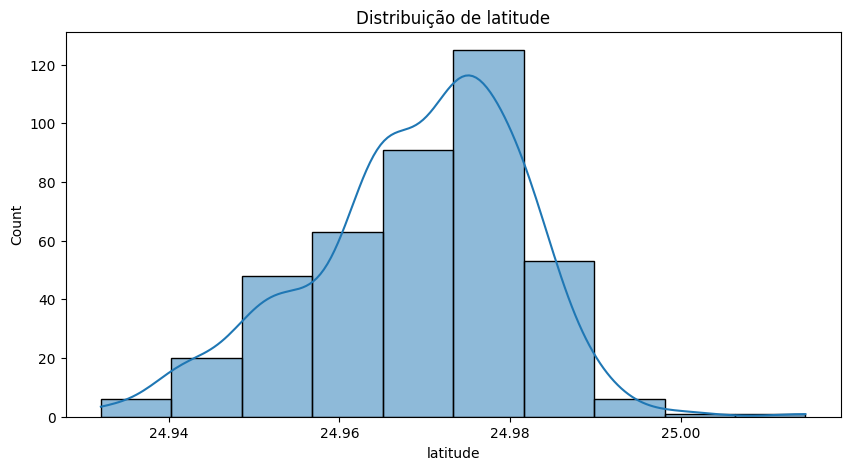

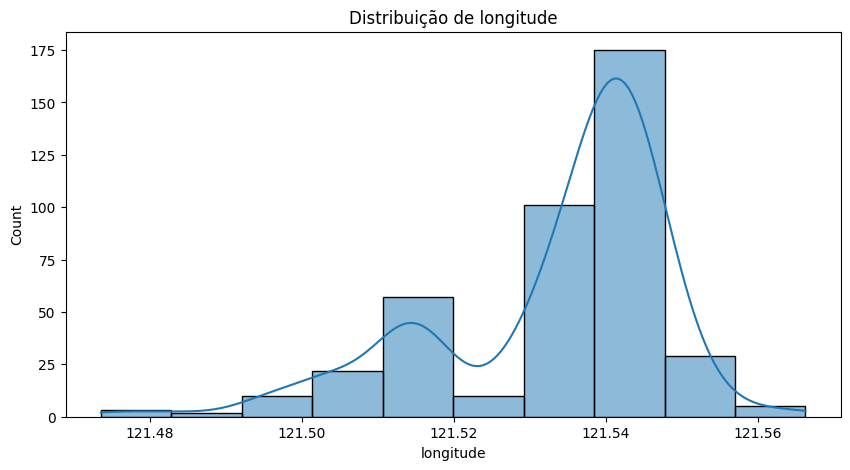

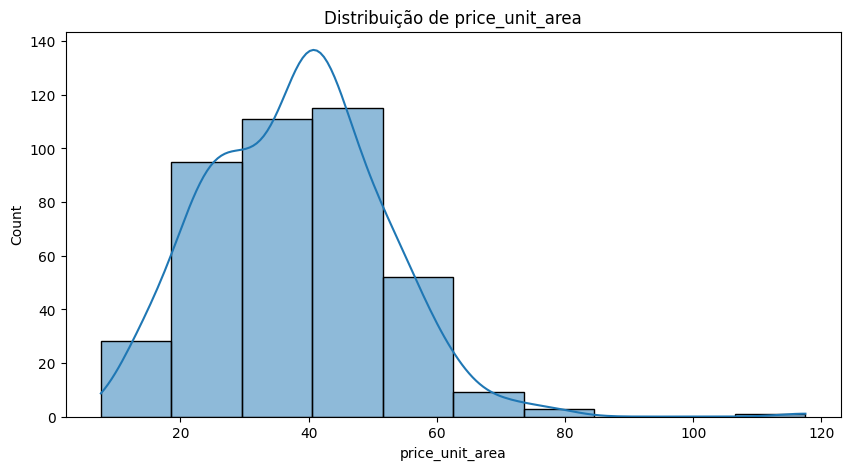

In [ ]:
#vendo histogramas
for i in df.columns:
  plt.figure(figsize=(10,5))  # Define o tamanho do gráfico
  sns.histplot(df[i], bins=10, kde=True)
  plt.title(f'Distribuição de {i}')  # Adiciona um título
  plt.show()

  #com os resultados pode se ver que os outliers desmonstrados nos plots de intervalo quartil, se tratam de representações práticas da realidade de compra.

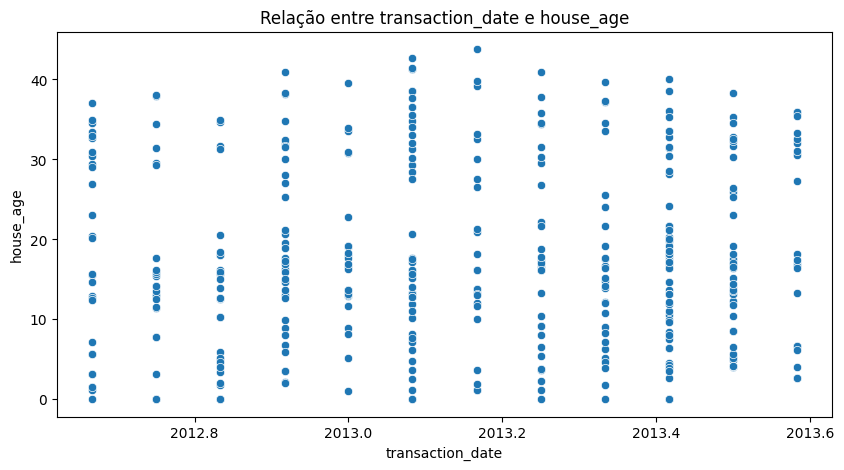

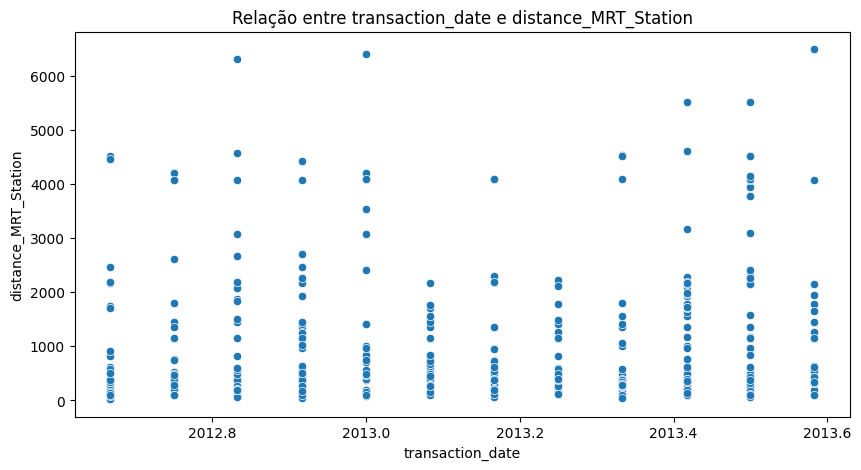

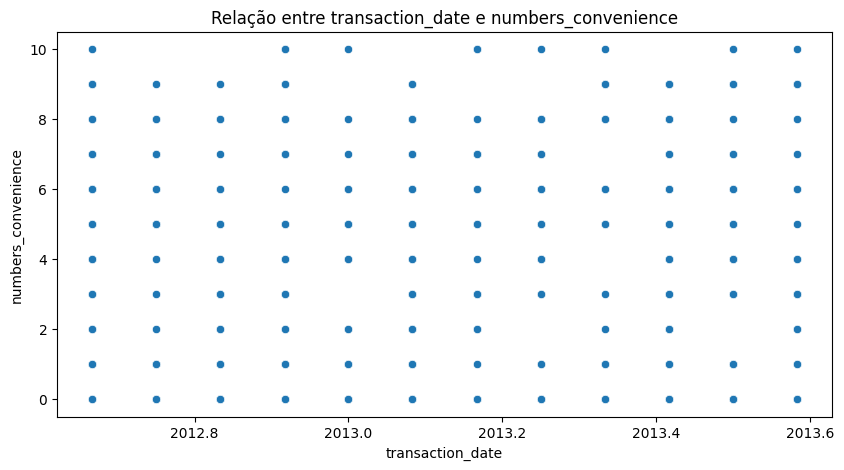

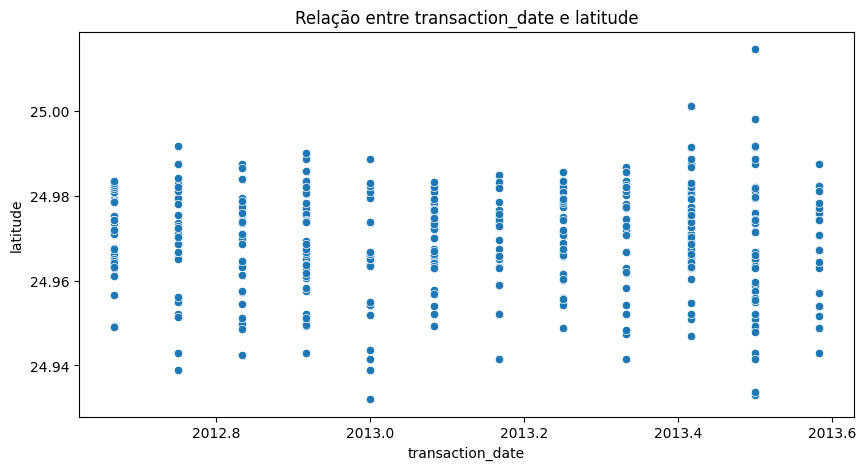

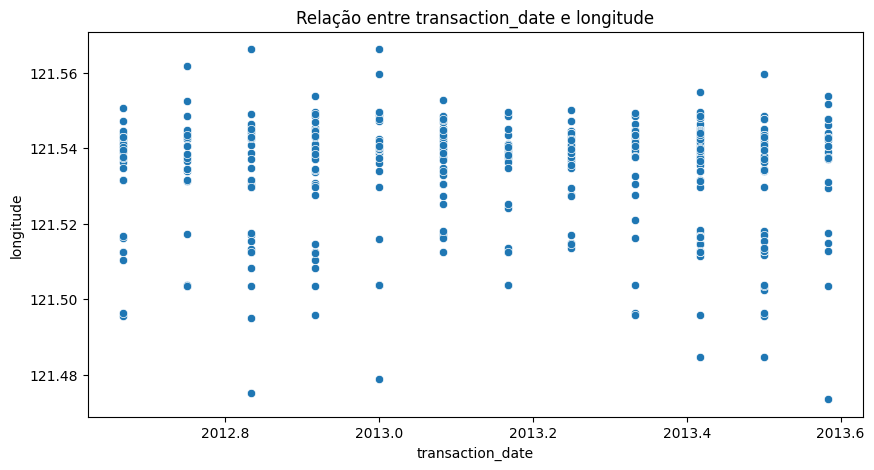

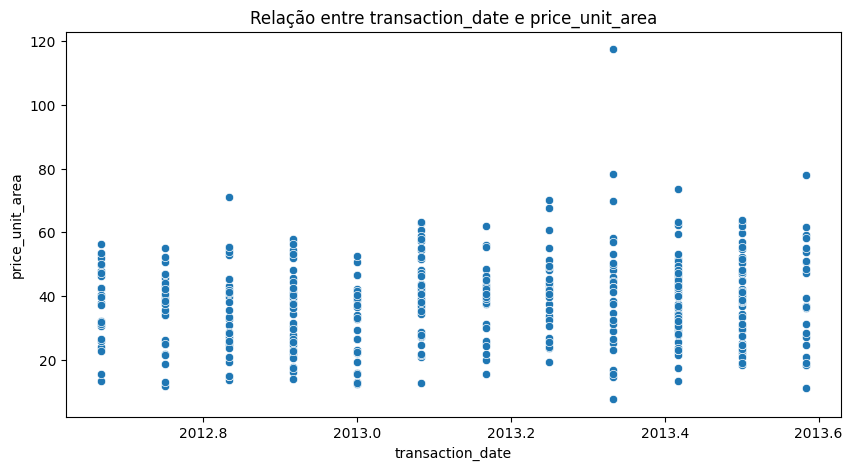

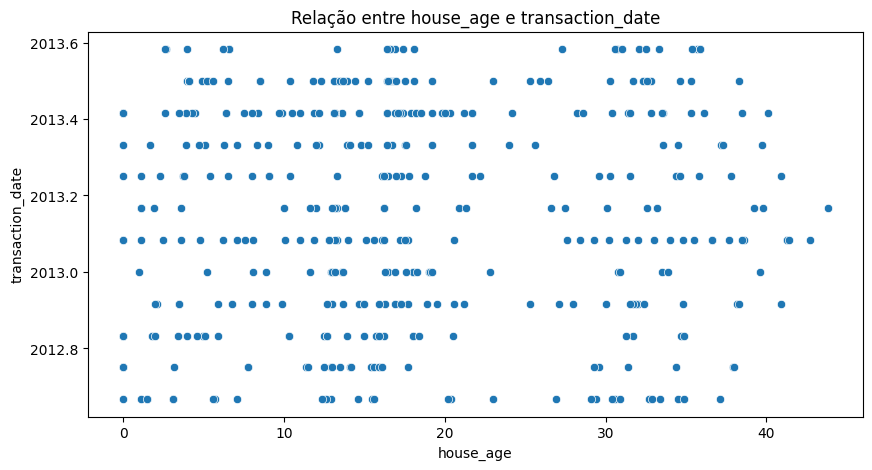

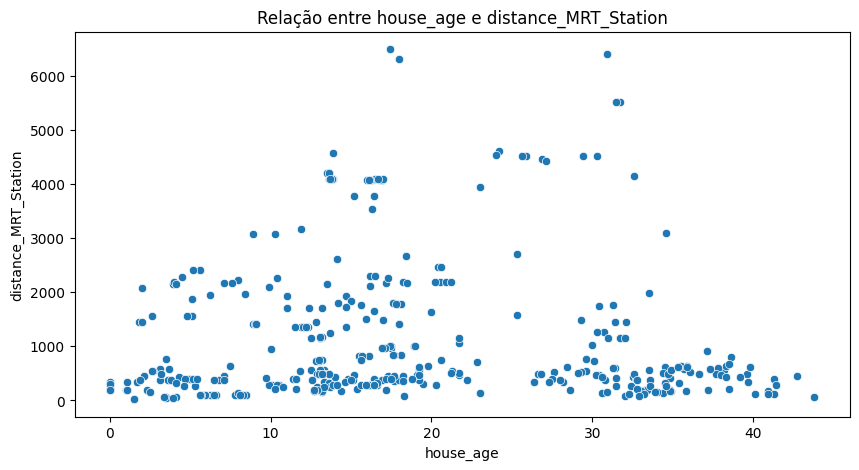

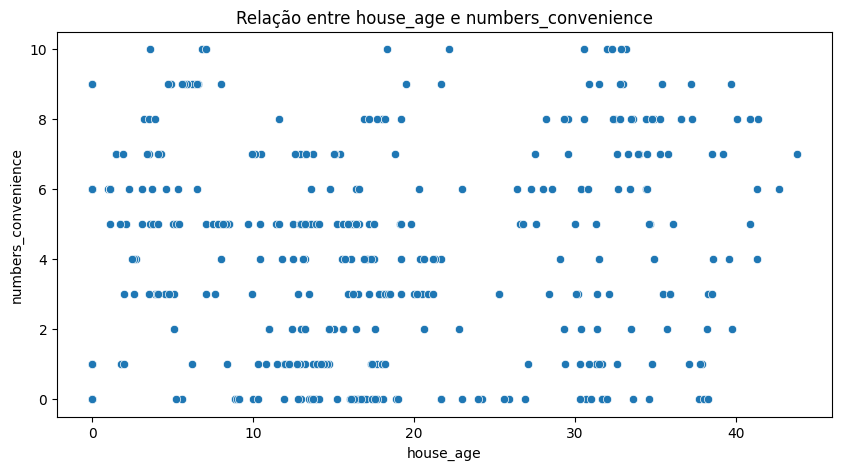

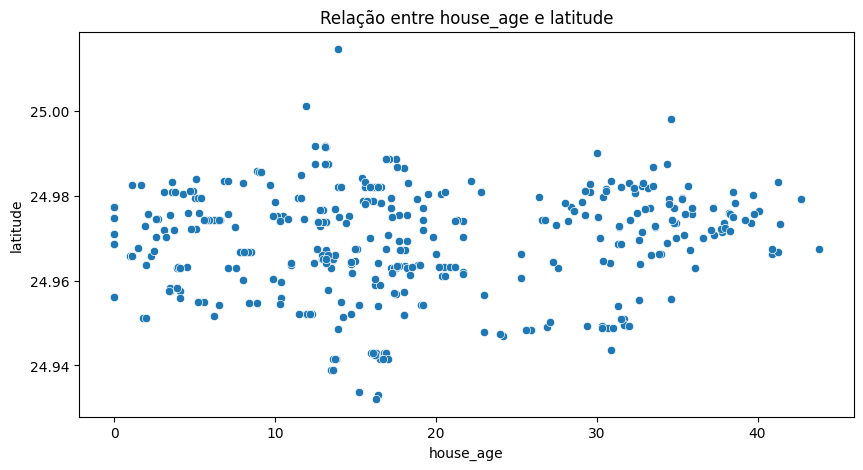

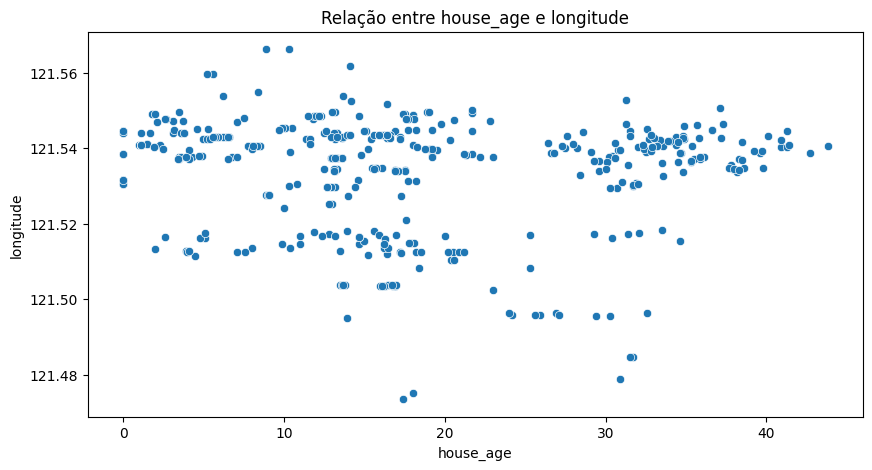

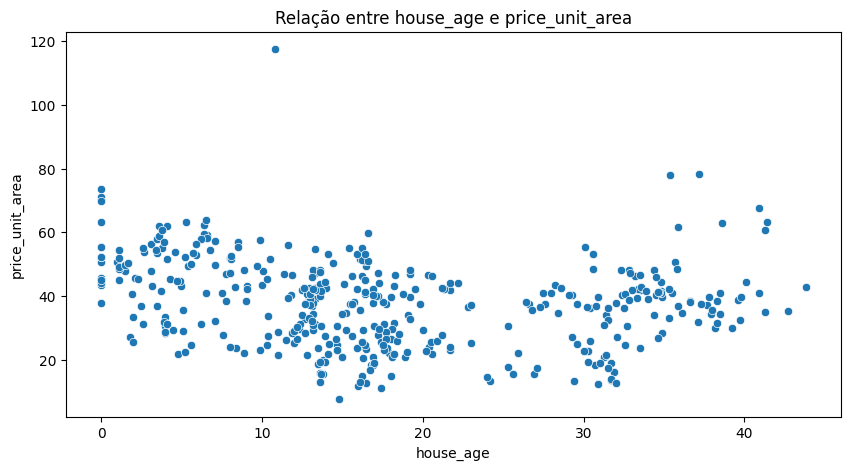

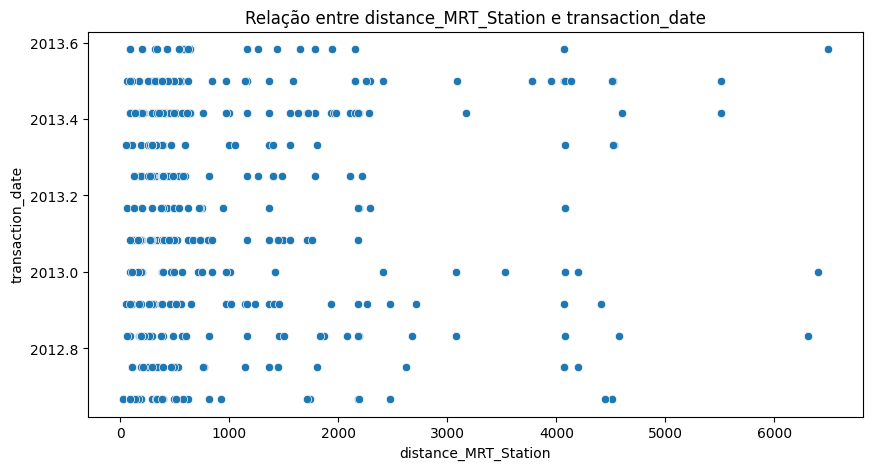

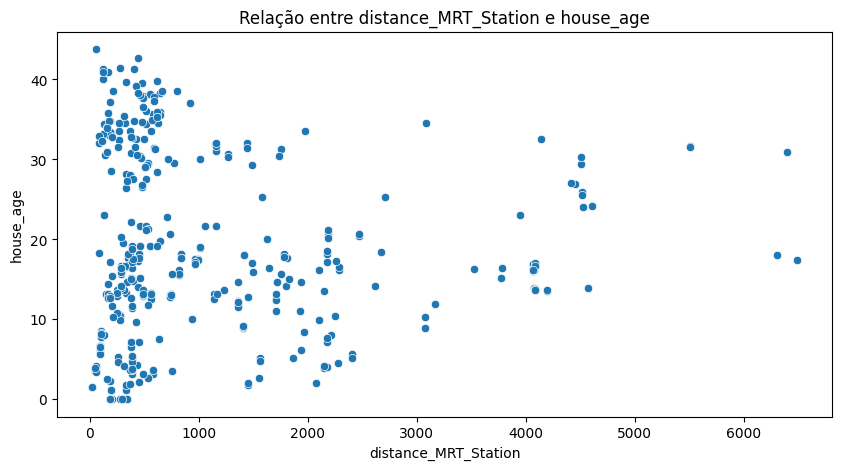

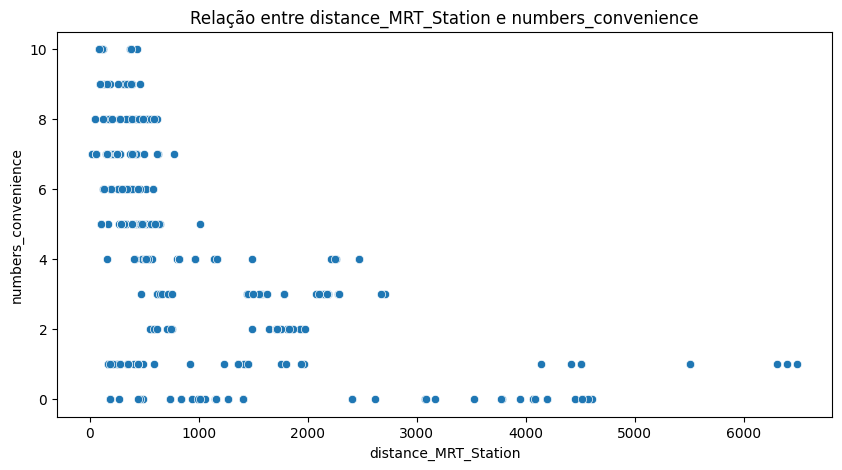

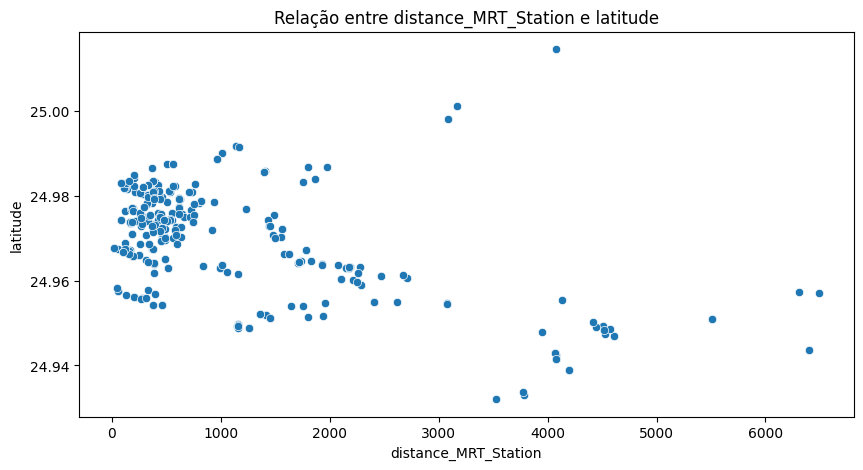

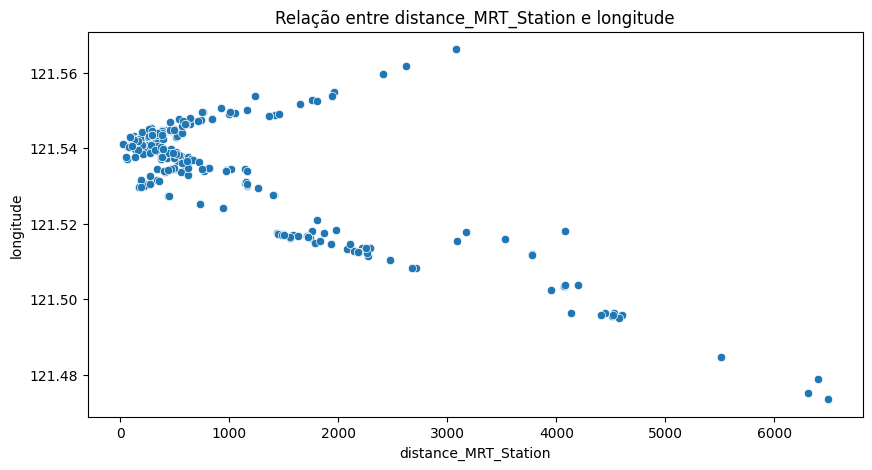

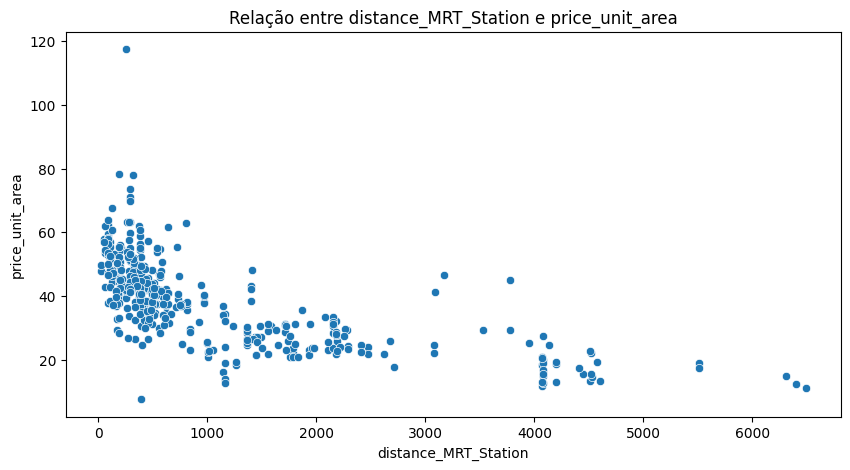

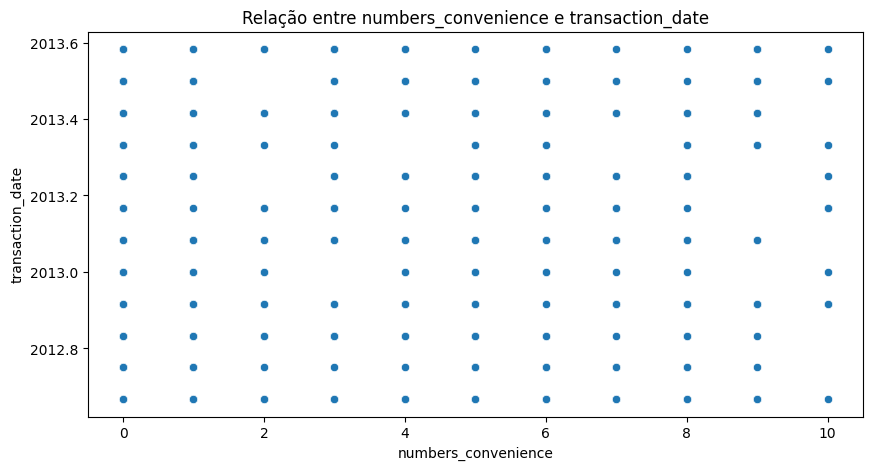

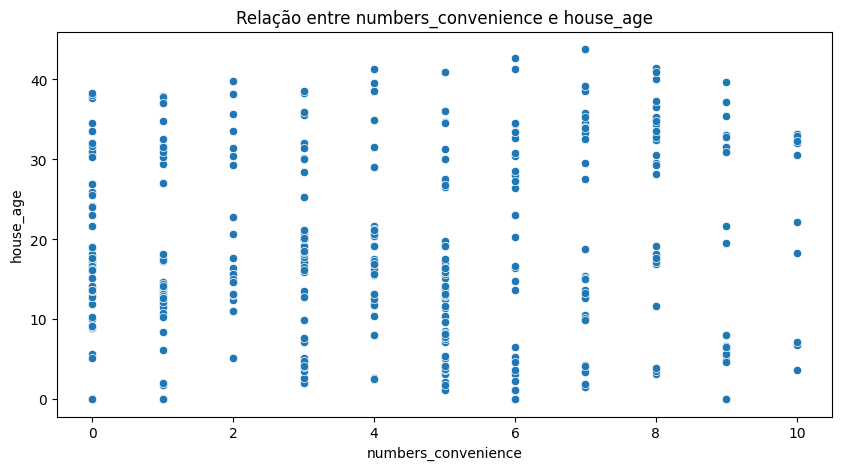

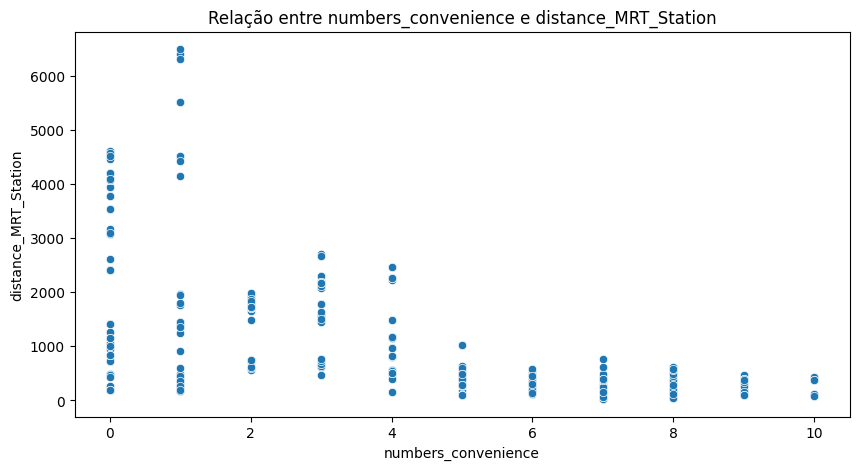

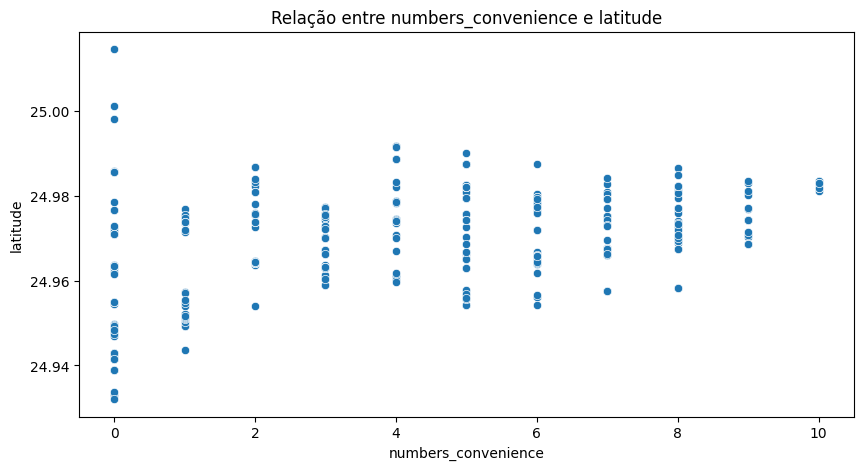

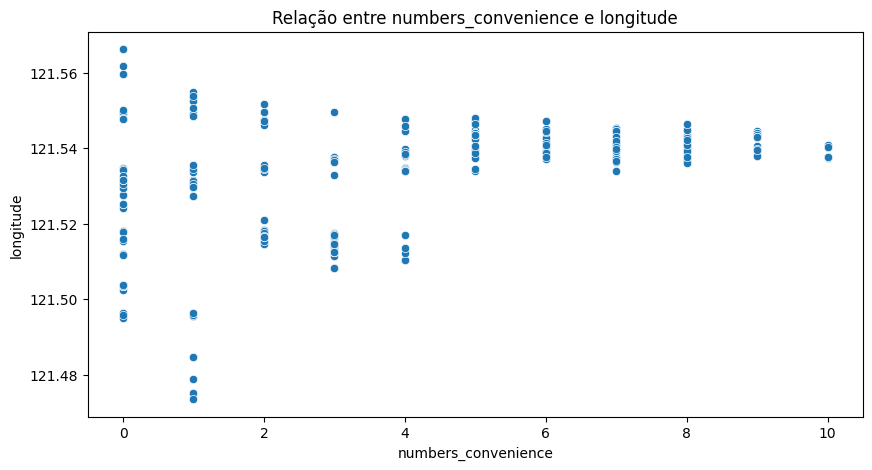

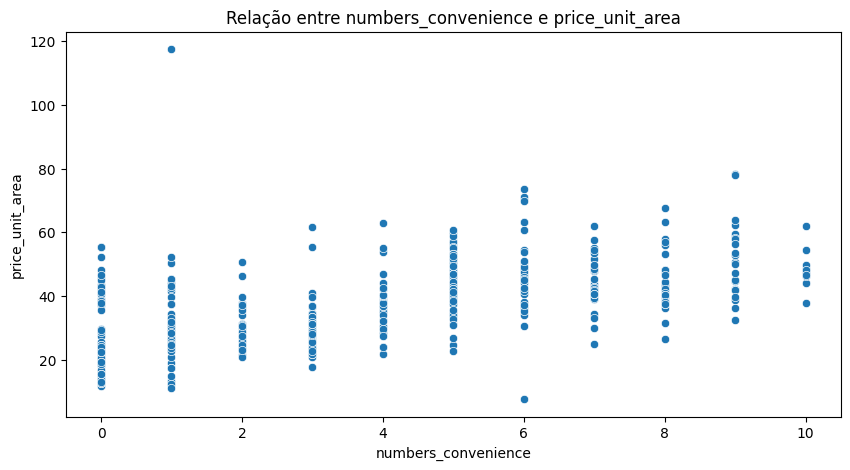

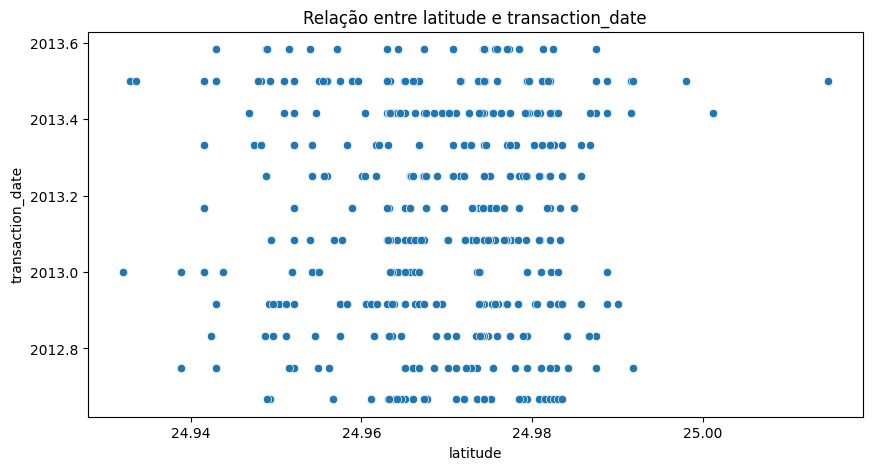

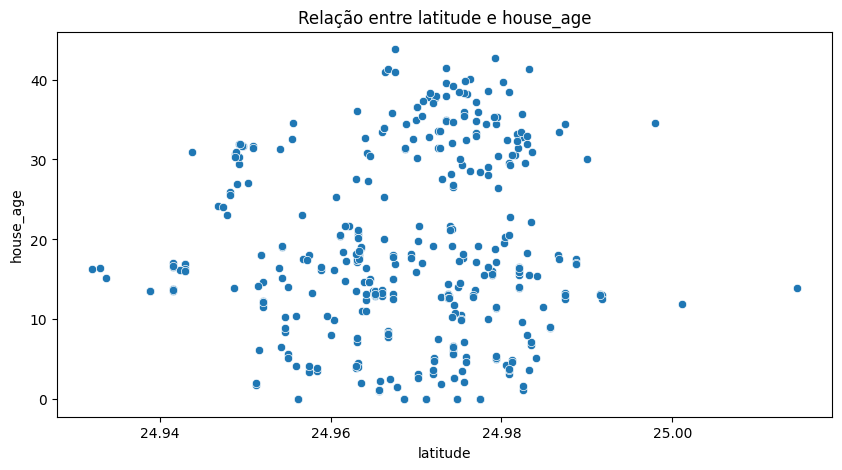

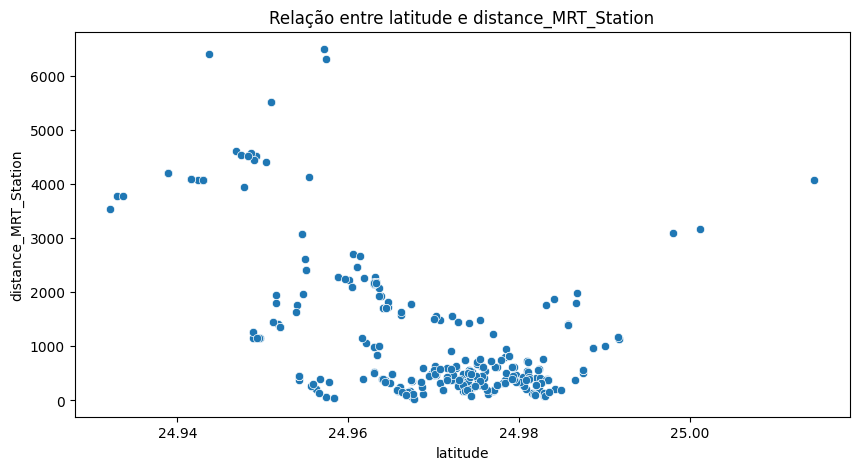

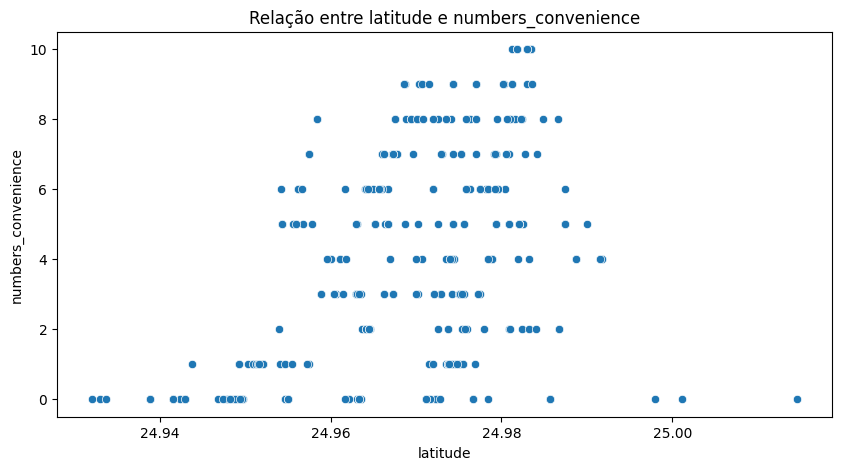

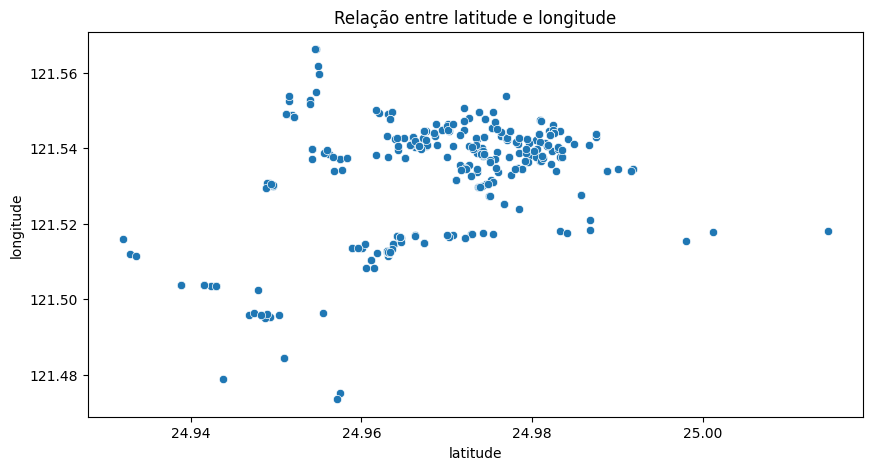

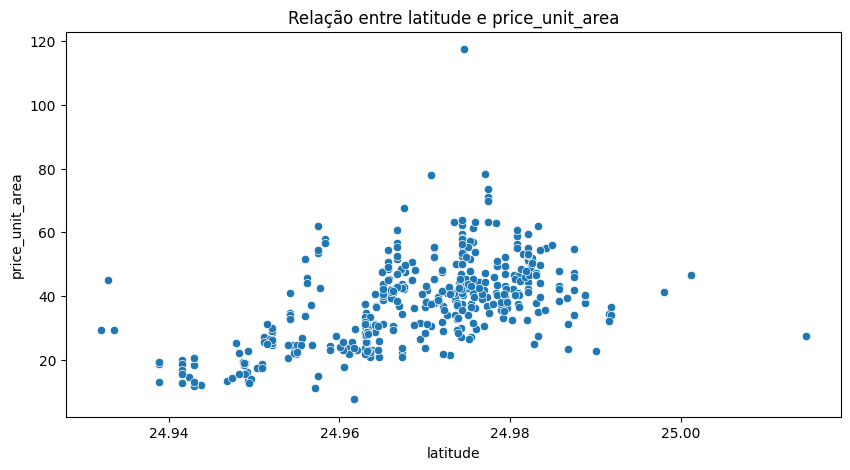

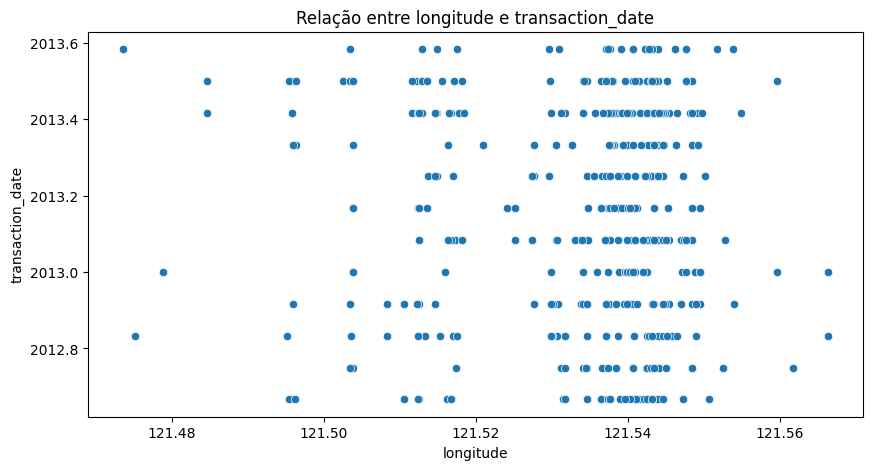

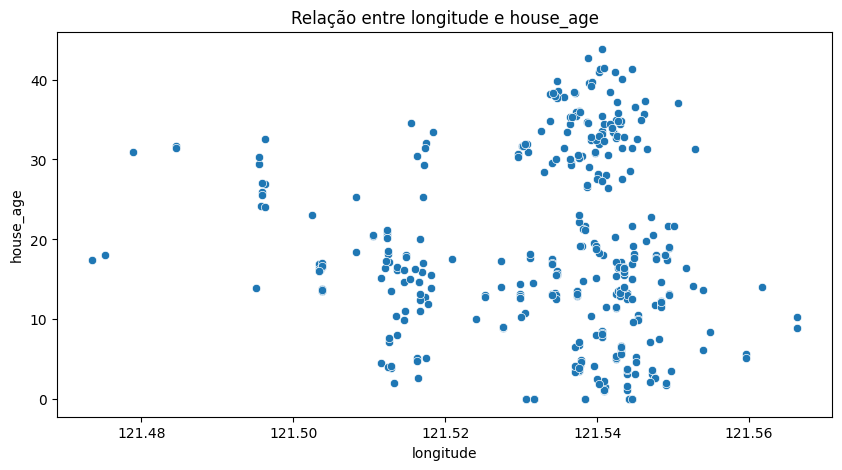

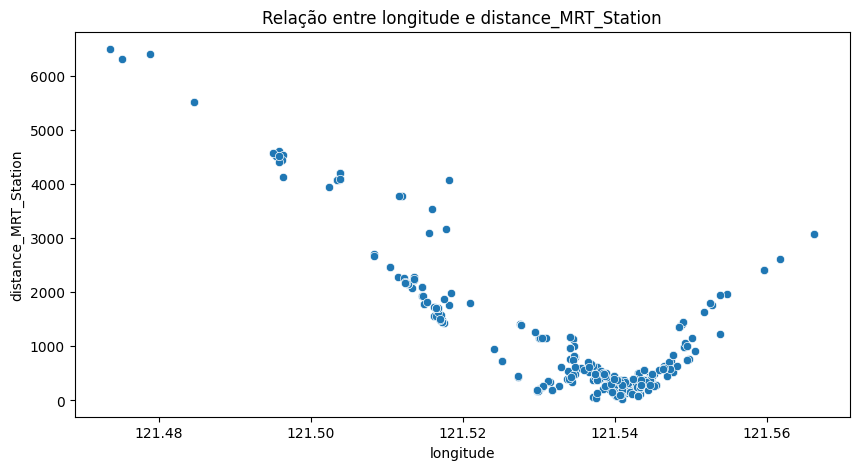

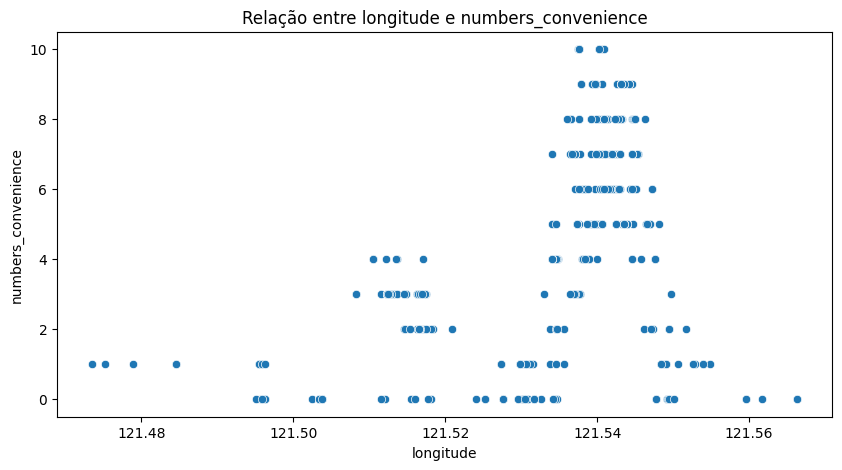

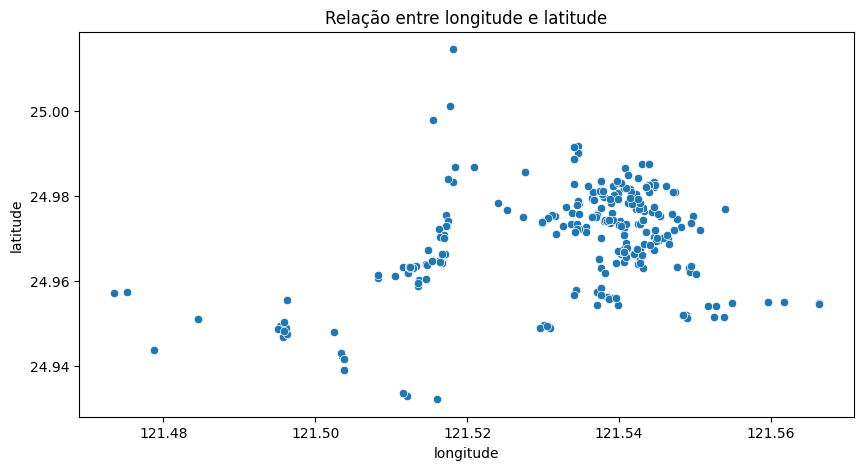

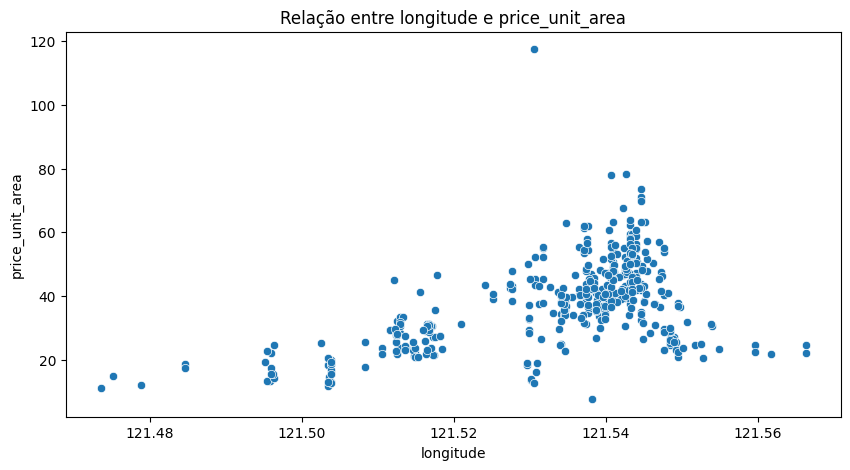

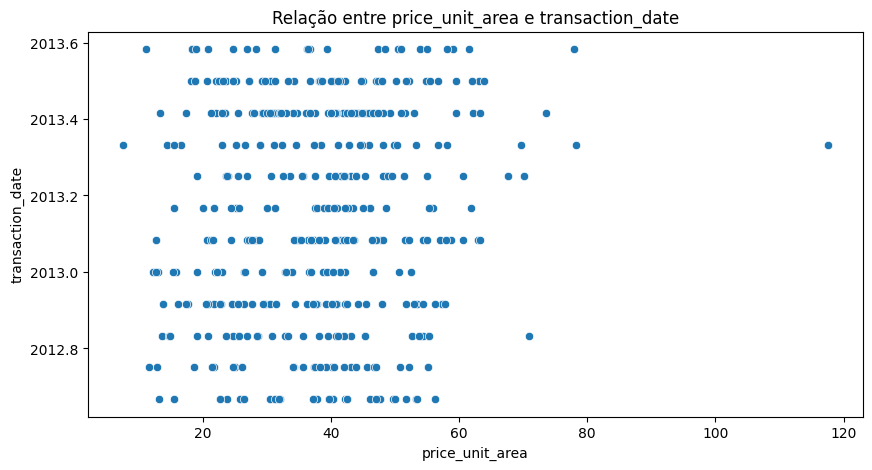

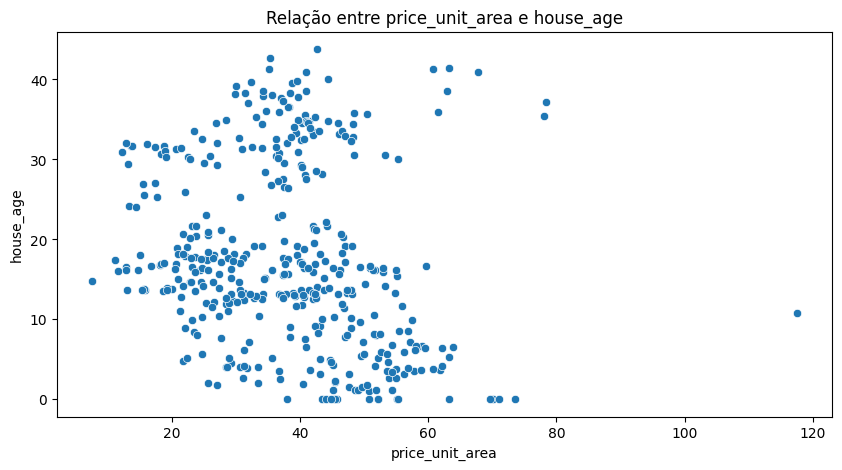

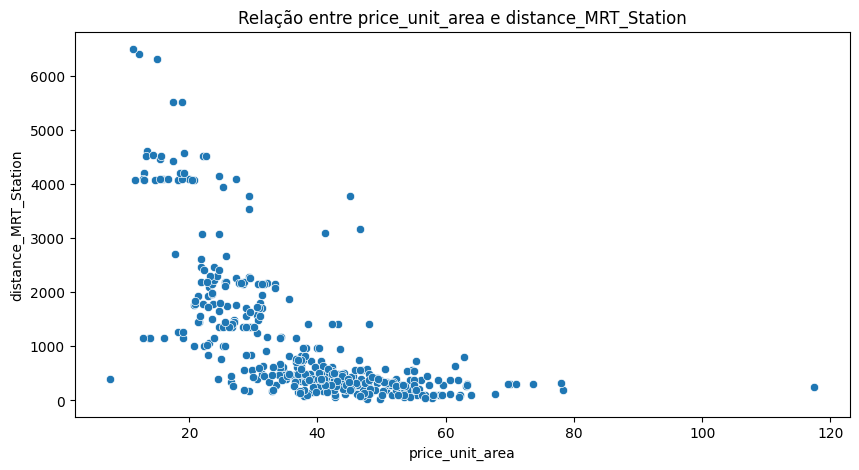

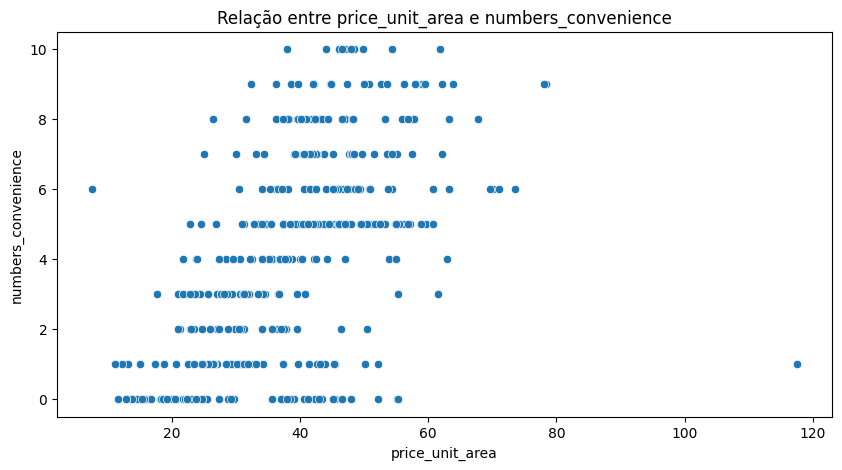

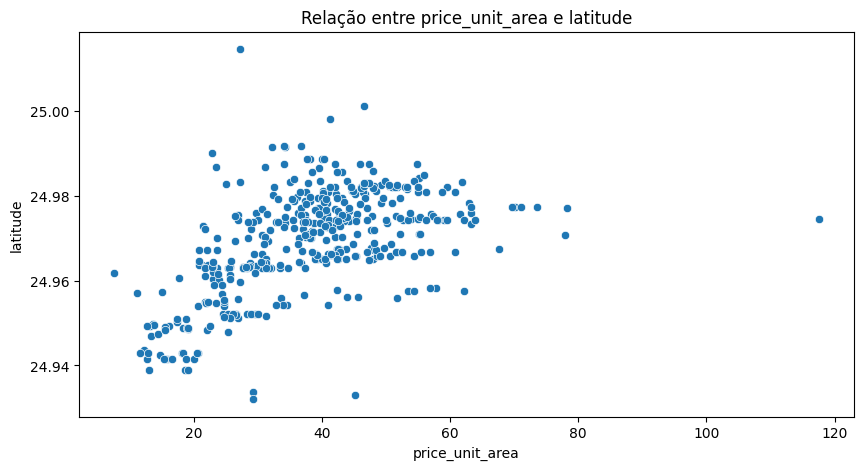

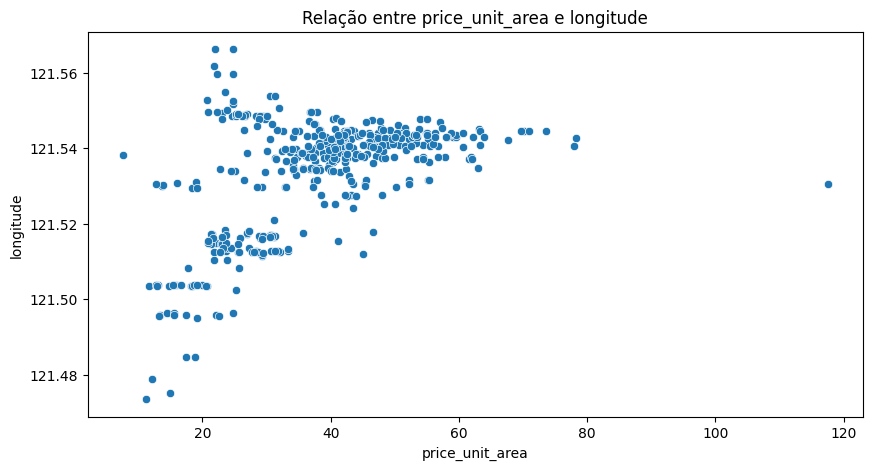

In [ ]:
#relação entre features
for i in df.columns:
  for x in df.columns:
    if (x != i):
      plt.figure(figsize=(10,5))
      sns.scatterplot(x=df[i], y=df[x])
      plt.title(f'Relação entre {i} e {x}')
      plt.show()

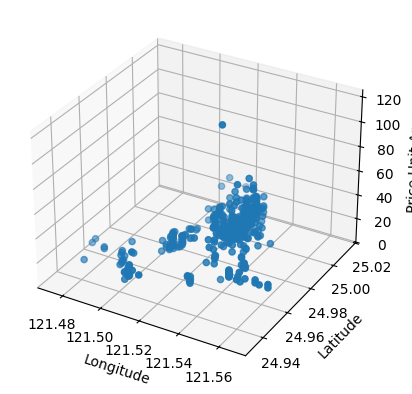

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['longitude'],
    df['latitude'],
    df['price_unit_area']
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Price Unit Area')

plt.show()

import plotly.express as px

fig = px.scatter_3d(
    df,
    x='longitude',
    y='latitude',
    z='price_unit_area',
    color='price_unit_area',
    color_continuous_scale='Turbo',
    labels={
        'longitude': 'Longitude',
        'latitude': 'Latitude',
        'price_unit_area': 'Preço por unidade de área'
    },
    title='Distribuição Espacial do Preço por Unidade de Área'
)

fig.update_traces(
    marker=dict(size=4)
)

fig.show()

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Criando uma grade
x = df['longitude']
y = df['latitude']
z = df['price_unit_area']

fig = go.Figure(data=[
    go.Mesh3d(
        x=x,
        y=y,
        z=z,
        intensity=z,
        colorscale='Viridis',
        opacity=0.8
    )
])

fig.update_layout(
    title='Superfície 3D do Preço por Localização',
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Preço'
    )
)

fig.show()


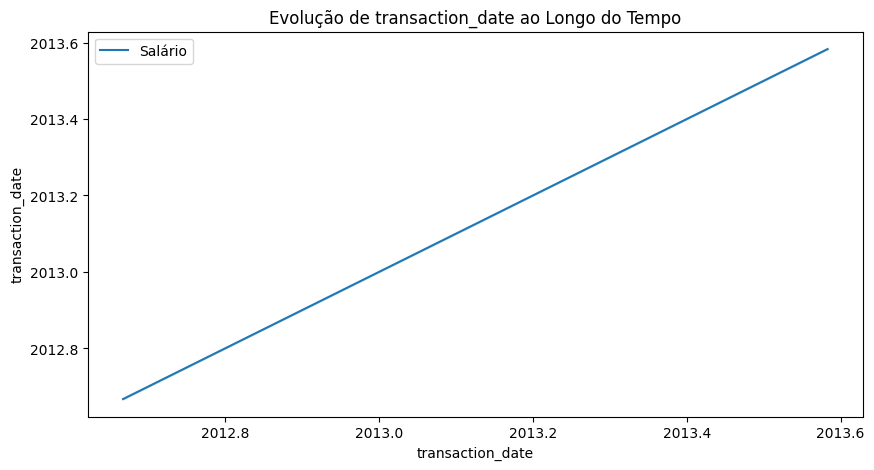

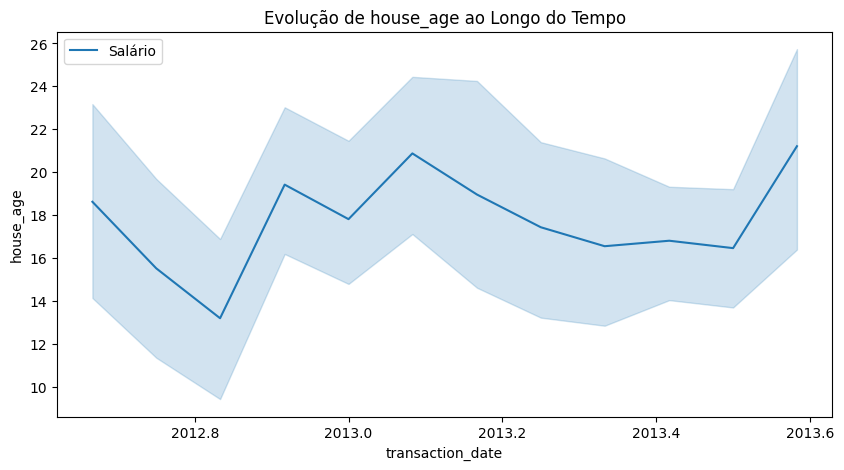

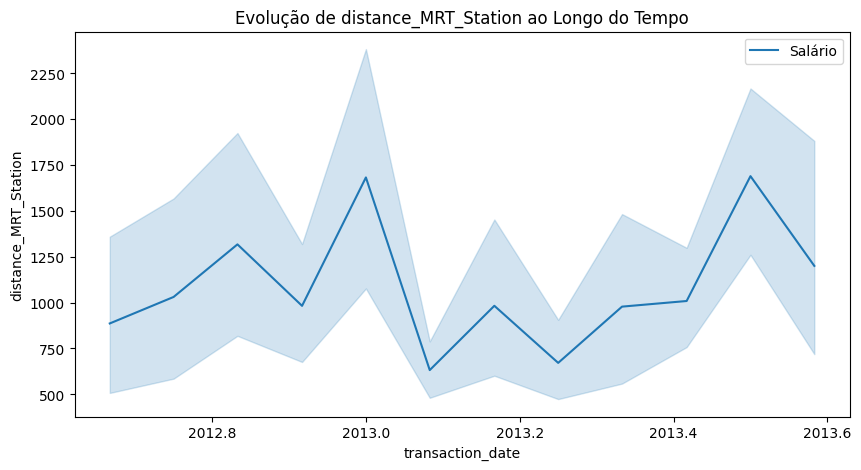

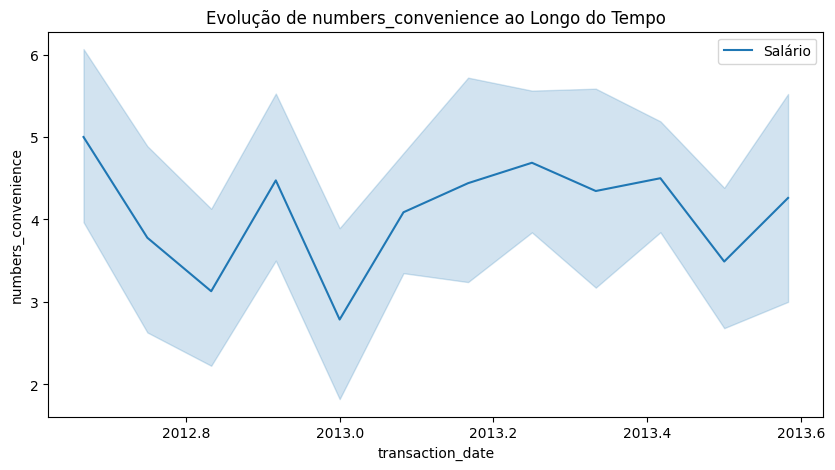

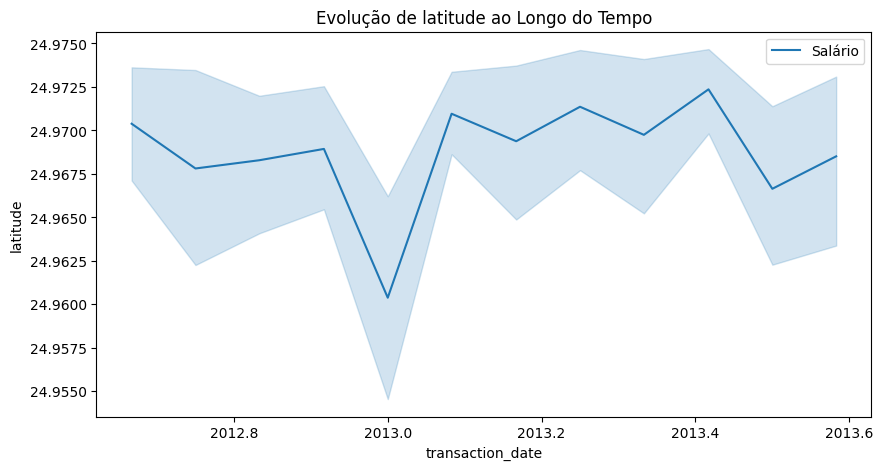

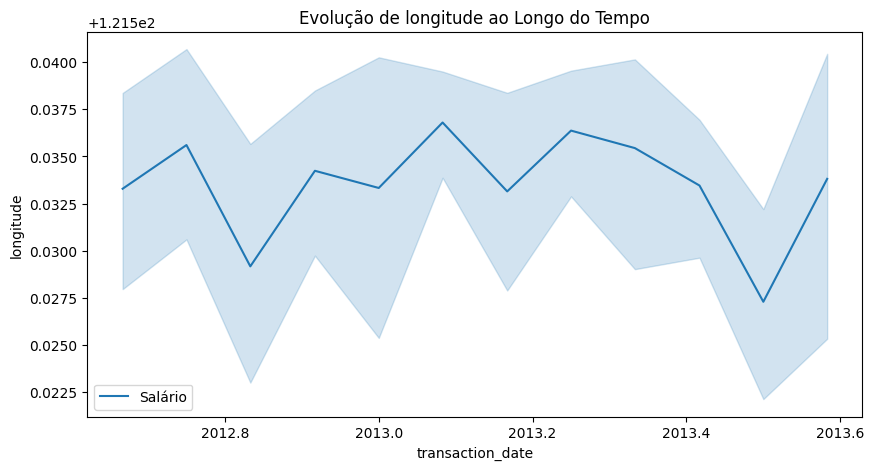

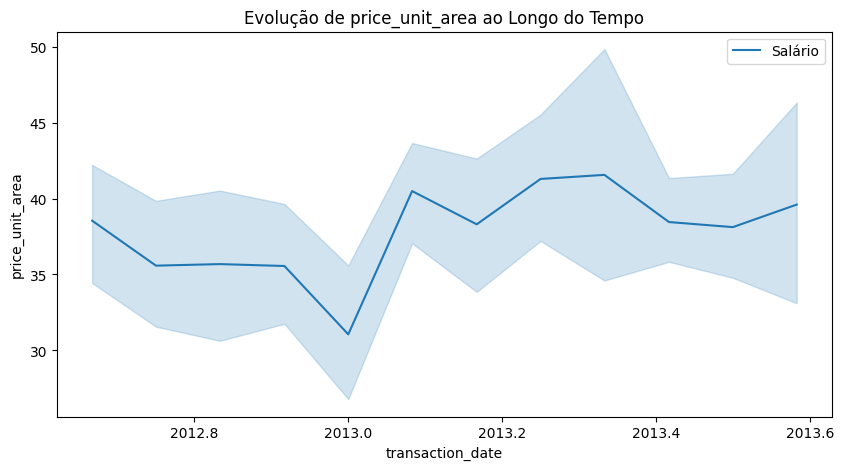

In [ ]:
for i in df.columns:
  plt.figure(figsize=(10,5))
  sns.lineplot(x=df['transaction_date'], y=df[i], label='Salário')
  plt.title(f'Evolução de {i} ao Longo do Tempo')
  plt.legend()
  plt.show()


In [ ]:
#dividindo em X e Y
X = df.drop(['price_unit_area'], axis=1)
Y = df['price_unit_area']

print(X)
print(Y)

     transaction_date  house_age  distance_MRT_Station  numbers_convenience  \
0            2012.917       32.0              84.87882                   10   
1            2012.917       19.5             306.59470                    9   
2            2013.583       13.3             561.98450                    5   
3            2013.500       13.3             561.98450                    5   
4            2012.833        5.0             390.56840                    5   
..                ...        ...                   ...                  ...   
409          2013.000       13.7            4082.01500                    0   
410          2012.667        5.6              90.45606                    9   
411          2013.250       18.8             390.96960                    7   
412          2013.000        8.1             104.81010                    5   
413          2013.500        6.5              90.45606                    9   

     latitude  longitude  
0    24.98298  121.54024

In [ ]:
#normalizando tipo 1
scaler = StandardScaler()
colunas = ['distance_MRT_Station', 'latitude', 'longitude']
X[colunas] = scaler.fit_transform(X[colunas])
print(df)

#normalizando features tipo 2
#Criando intervalos de idade e coniencias
idade_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100]
idade_labels = ['0-5 anos', '6-10 anos', '11-15 anos', '16-20 anos', '21-25 anos', '26-30 anos', '31-35 anos', '36-40 anos', '41-45 anos', '46-50 anos', '>50 anos']
X['house_age_interval'] = pd.cut(X['house_age'], bins=idade_bins, labels=idade_labels, right=False)
X = pd.get_dummies(X, columns=['house_age_interval'], prefix='house_age')
X = X.drop(columns=['house_age'])

stores_bins = [-1, 0, 3, 6, 10, 20]
stores_labels = ['Nenhum', '1-3 Lojas', '4-6 Lojas', '7-10 Lojas', '>10 Lojas']
X['numbers_convenience_interval'] = pd.cut(X['numbers_convenience'], bins=stores_bins, labels=stores_labels, right=True)
X = pd.get_dummies(X, columns=['numbers_convenience_interval'], prefix='convenience')
X = X.drop(columns=['numbers_convenience'])

transaction_bins = [2012.5, 2012.7, 2012.9, 2013.1, 2013.3, 2013.6]
transaction_labels = ['2012.5-2012.7', '2012.7-2012.9', '2012.9-2013.1', '2013.1-2013.3', '2013.3-2013.6']
X['transaction_date_interval'] = pd.cut(X['transaction_date'], bins=transaction_bins, labels=transaction_labels, right=False)
X = pd.get_dummies(X, columns=['transaction_date_interval'], prefix='trasaction')
X = X.drop(columns=['transaction_date'])

#normalizando stdscaler distance da estaçao, latitude e longitude
scaler = StandardScaler()
X['distance_MRT_Station_scaled'] = scaler.fit_transform(X[['distance_MRT_Station']])
X = X.drop(columns=['distance_MRT_Station'])

X['latitude_scaled'] = scaler.fit_transform(X[['latitude']])
X = X.drop(columns=['latitude'])

X['longitude_scaled'] = scaler.fit_transform(X[['longitude']])
X = X.drop(columns=['longitude'])

     transaction_date  house_age  distance_MRT_Station  numbers_convenience  \
0            2012.917       32.0              84.87882                   10   
1            2012.917       19.5             306.59470                    9   
2            2013.583       13.3             561.98450                    5   
3            2013.500       13.3             561.98450                    5   
4            2012.833        5.0             390.56840                    5   
..                ...        ...                   ...                  ...   
409          2013.000       13.7            4082.01500                    0   
410          2012.667        5.6              90.45606                    9   
411          2013.250       18.8             390.96960                    7   
412          2013.000        8.1             104.81010                    5   
413          2013.500        6.5              90.45606                    9   

     latitude  longitude  price_unit_area  
0    24

In [ ]:
#instanciando kfold
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#modelos
modelos = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor()
}

#parametros
param_grids = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 6]
    }
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
erros_baseline = y_test - y_pred_baseline

for nome_modelo, modelo in modelos.items():
    print(f"Otimizando hiperparâmetros para {nome_modelo}...")
    grid_search = GridSearchCV(modelo, param_grids[nome_modelo],
                               cv=kf,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1)

    grid_search.fit(X_train, y_train)

    melhor_modelo = grid_search.best_estimator_
    melhores_params = grid_search.best_params_
    melhor_score_cv = -grid_search.best_score_

    y_pred_test = melhor_modelo.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    resultados[nome_modelo] = {
        'melhor_modelo': melhor_modelo,
        'melhores_params': melhores_params,
        'rmse_cv': melhor_score_cv**0.5,
        'rmse_teste': rmse_test,
        'mae_teste': mae_test,
        'r2_teste': r2_test
    }

print("Otimização de hiperparâmetros e avaliação concluídas.\nResultados:")
for nome_modelo, resultado in resultados.items():
    print(f"\nModelo: {nome_modelo}")
    print(f"  Melhores Hiperparâmetros: {resultado['melhores_params']}")
    print(f"  RMSE (Validação Cruzada): {resultado['rmse_cv']:.2f}")
    print(f"  RMSE (Teste): {resultado['rmse_teste']:.2f}")
    print(f"  MAE (Teste): {resultado['mae_teste']:.2f}")
    print(f"  R² (Teste): {resultado['r2_teste']:.3f}")

Otimizando hiperparâmetros para Linear Regression...
Otimizando hiperparâmetros para Decision Tree...
Otimizando hiperparâmetros para Random Forest...
Otimizando hiperparâmetros para XGBoost...
Otimização de hiperparâmetros e avaliação concluídas.
Resultados:

Modelo: Linear Regression
  Melhores Hiperparâmetros: {}
  RMSE (Validação Cruzada): 9.41
  RMSE (Teste): 6.65
  MAE (Teste): 5.09
  R² (Teste): 0.736

Modelo: Decision Tree
  Melhores Hiperparâmetros: {'max_depth': 5, 'min_samples_split': 5}
  RMSE (Validação Cruzada): 9.11
  RMSE (Teste): 5.83
  MAE (Teste): 4.30
  R² (Teste): 0.797

Modelo: Random Forest
  Melhores Hiperparâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
  RMSE (Validação Cruzada): 8.35
  RMSE (Teste): 5.84
  MAE (Teste): 4.09
  R² (Teste): 0.797

Modelo: XGBoost
  Melhores Hiperparâmetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
  RMSE (Validação Cruzada): 8.33
  RMSE (Teste): 6.41
  MAE (Teste): 4.83
  R² (Teste)

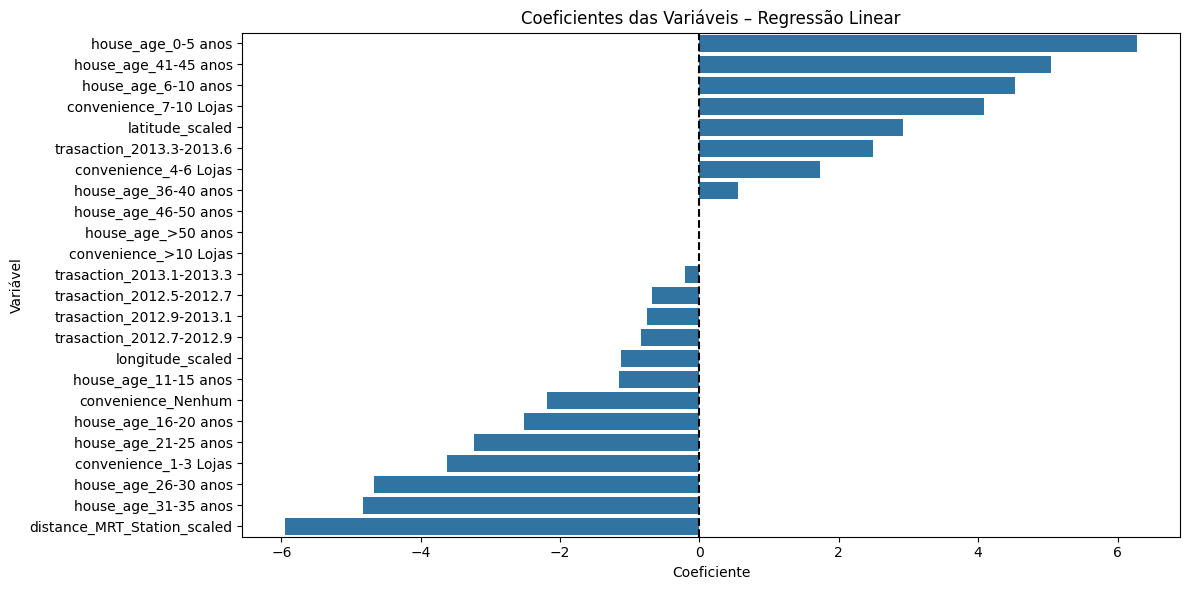

                       Variável  Importância
21  distance_MRT_Station_scaled     0.632184
22              latitude_scaled     0.133984
23             longitude_scaled     0.102116
0            house_age_0-5 anos     0.020199
20     trasaction_2013.3-2013.6     0.017802
6          house_age_31-35 anos     0.014846
7          house_age_36-40 anos     0.013194
12        convenience_1-3 Lojas     0.011739
1           house_age_6-10 anos     0.009905
2          house_age_11-15 anos     0.006471


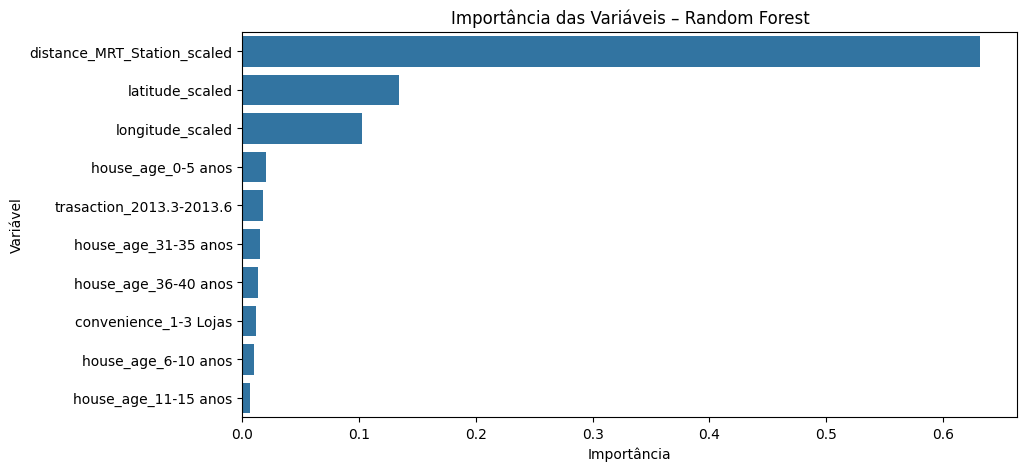

In [ ]:
linear_model = resultados['Linear Regression']['melhor_modelo']

coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': linear_model.coef_
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Coeficiente',
    y='Variável',
    data=coef_df
)
plt.axvline(0, color='black', linestyle='--')
plt.title('Coeficientes das Variáveis – Regressão Linear')
plt.tight_layout()
plt.show()

rf_model = resultados['Random Forest']['melhor_modelo']

importances_df = pd.DataFrame({
    'Variável': X.columns,
    'Importância': rf_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

print(importances_df.head(10))

plt.figure(figsize=(10,5))
sns.barplot(
    x='Importância',
    y='Variável',
    data=importances_df.head(10)
)
plt.title('Importância das Variáveis – Random Forest')
plt.show()


                       Variável  Importância
21  distance_MRT_Station_scaled     0.762067
22              latitude_scaled     0.092559
23             longitude_scaled     0.064129
6          house_age_31-35 anos     0.032354
0            house_age_0-5 anos     0.024098
1           house_age_6-10 anos     0.014072
11           convenience_Nenhum     0.005183
18     trasaction_2012.9-2013.1     0.002798
12        convenience_1-3 Lojas     0.002428
4          house_age_21-25 anos     0.000240


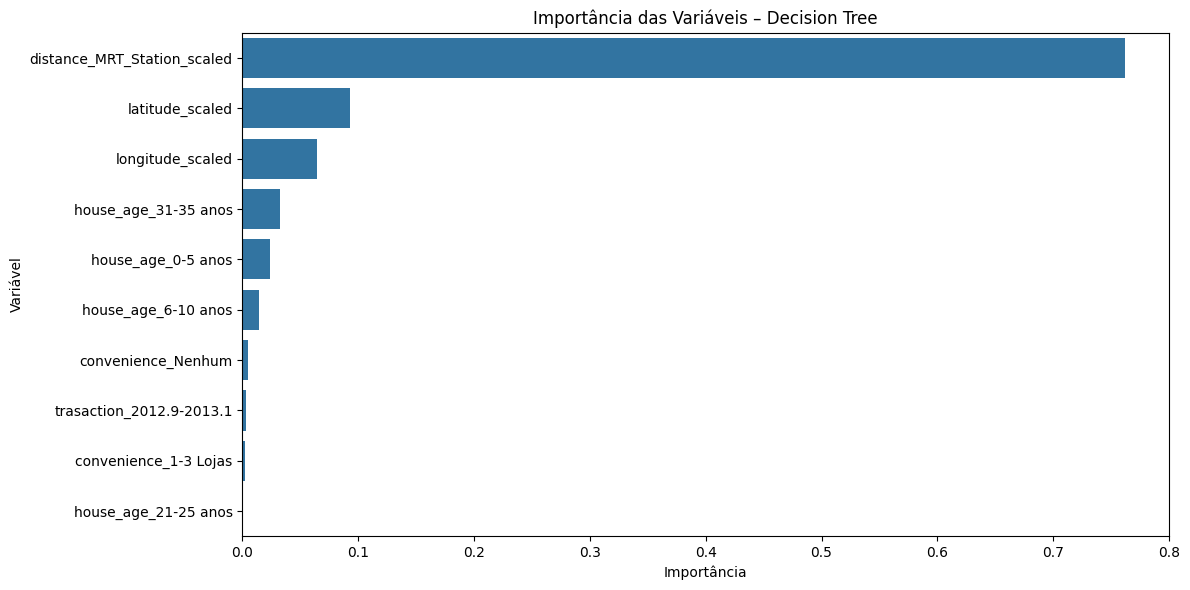

In [ ]:
dt_model = resultados['Decision Tree']['melhor_modelo']

dt_importances = pd.DataFrame({
    'Variável': X.columns,
    'Importância': dt_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

print(dt_importances.head(10))

plt.figure(figsize=(12,6))
sns.barplot(
    x='Importância',
    y='Variável',
    data=dt_importances.head(10)
)
plt.title('Importância das Variáveis – Decision Tree')
plt.tight_layout()
plt.show()


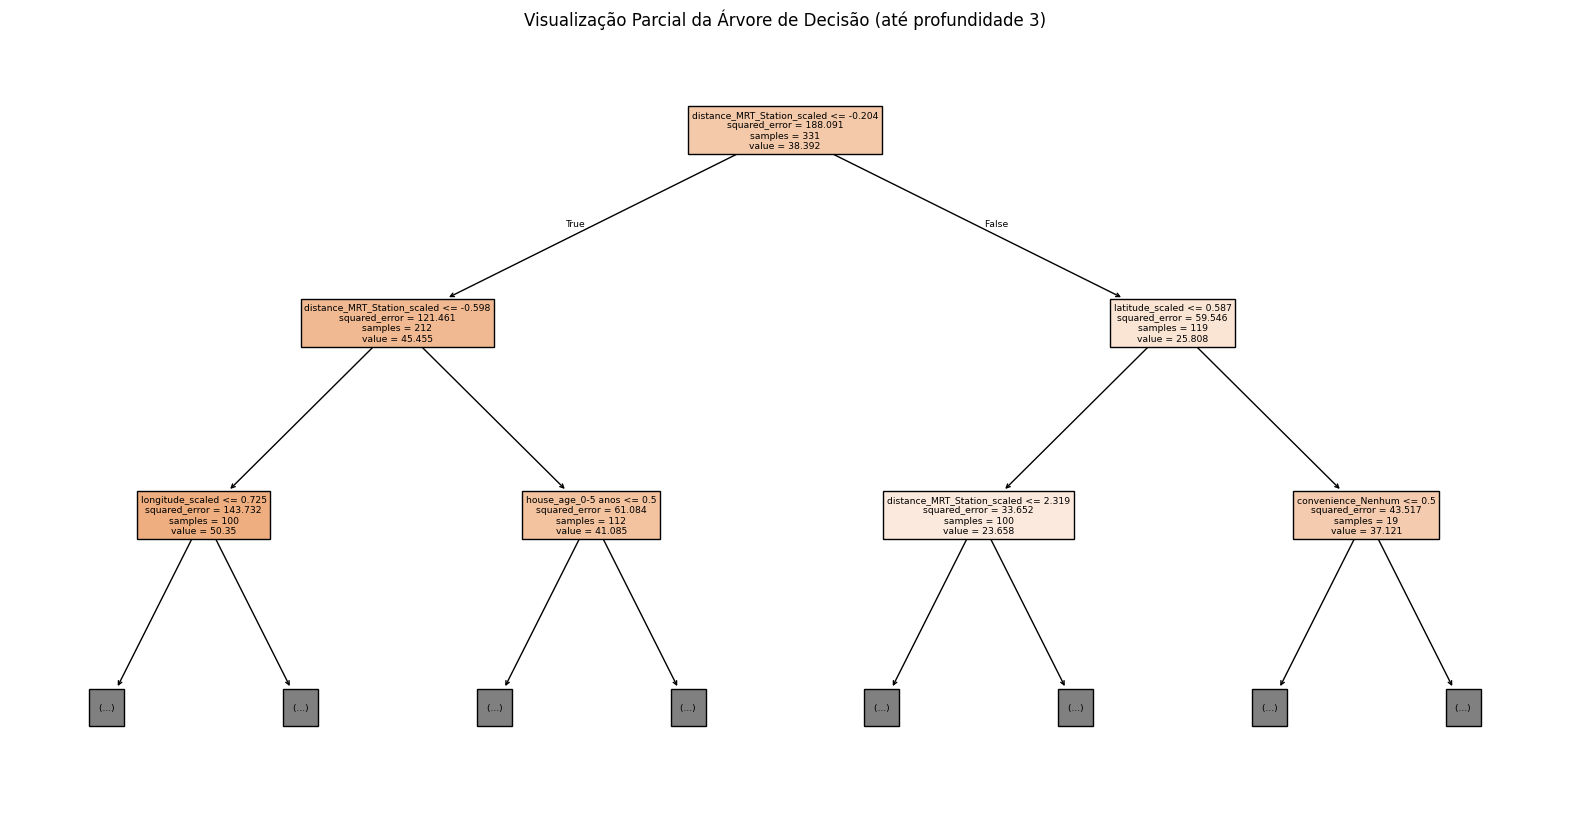

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True,
    max_depth=2
)
plt.title('Visualização Parcial da Árvore de Decisão (até profundidade 3)')
plt.show()


                       Variável  Importância
21  distance_MRT_Station_scaled     0.406713
12        convenience_1-3 Lojas     0.115237
20     trasaction_2013.3-2013.6     0.072105
22              latitude_scaled     0.069253
23             longitude_scaled     0.066516
0            house_age_0-5 anos     0.062880
6          house_age_31-35 anos     0.060430
13        convenience_4-6 Lojas     0.045793
1           house_age_6-10 anos     0.038295
17     trasaction_2012.7-2012.9     0.018200


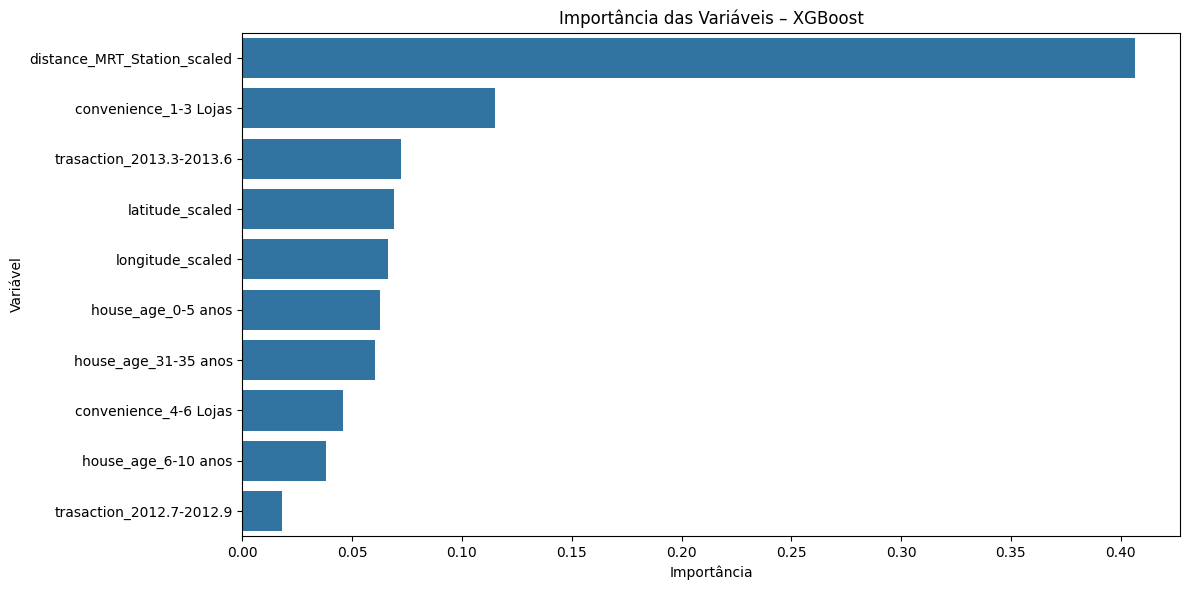

In [ ]:
xgb_model = resultados['XGBoost']['melhor_modelo']

xgb_importances = pd.DataFrame({
    'Variável': X.columns,
    'Importância': xgb_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

print(xgb_importances.head(10))

plt.figure(figsize=(12,6))
sns.barplot(
    x='Importância',
    y='Variável',
    data=xgb_importances.head(10)
)
plt.title('Importância das Variáveis – XGBoost')
plt.tight_layout()
plt.show()


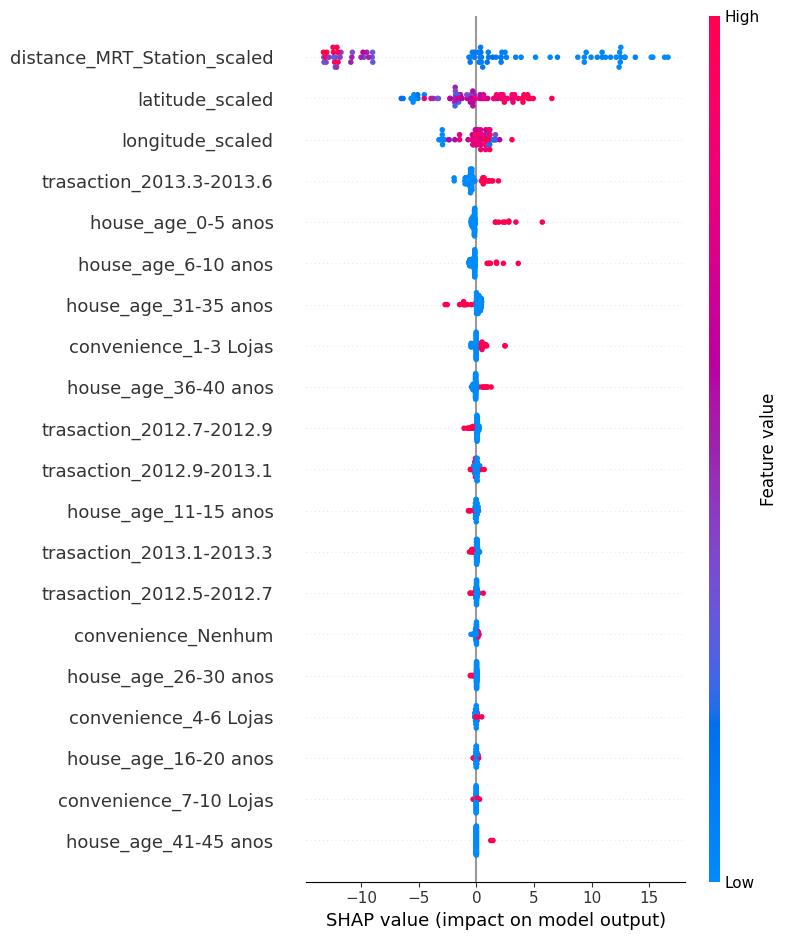

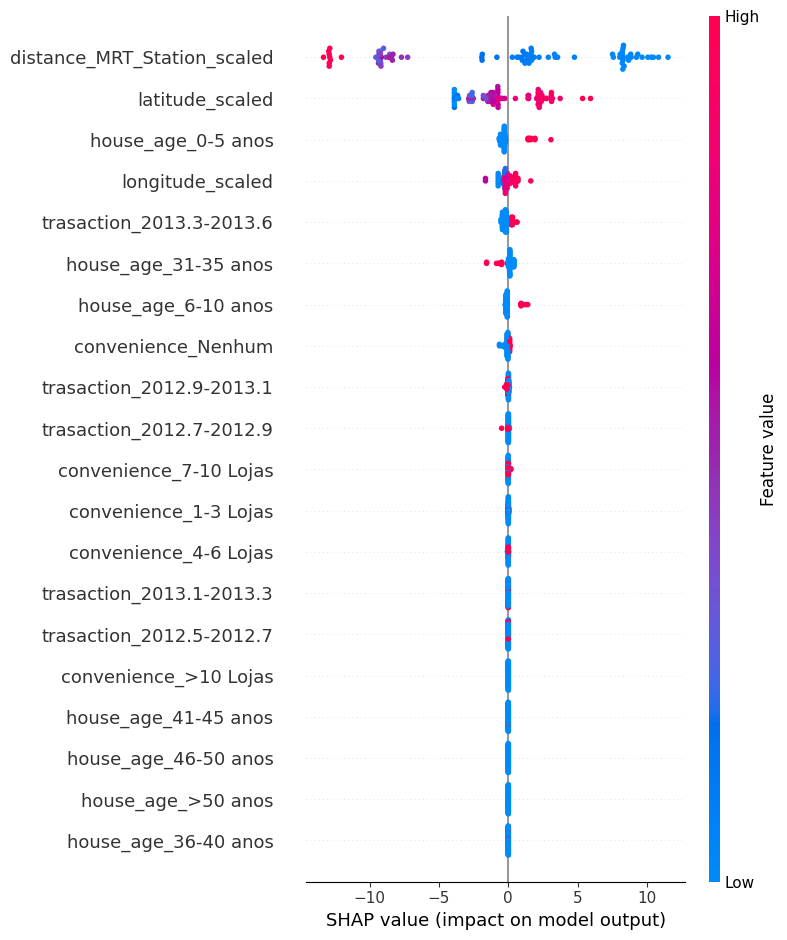

In [ ]:
!pip install shap
import shap

# Garantindo dados numéricos para o SHAP
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# Criando o explainer
explainer = shap.Explainer(rf_model, X_train_shap)

# Calculando valores SHAP
shap_values = explainer(X_test_shap)

# Gráfico global de explicabilidade
shap.summary_plot(shap_values, X_test_shap)


explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_shap)

shap.summary_plot(shap_values_xgb, X_test_shap)


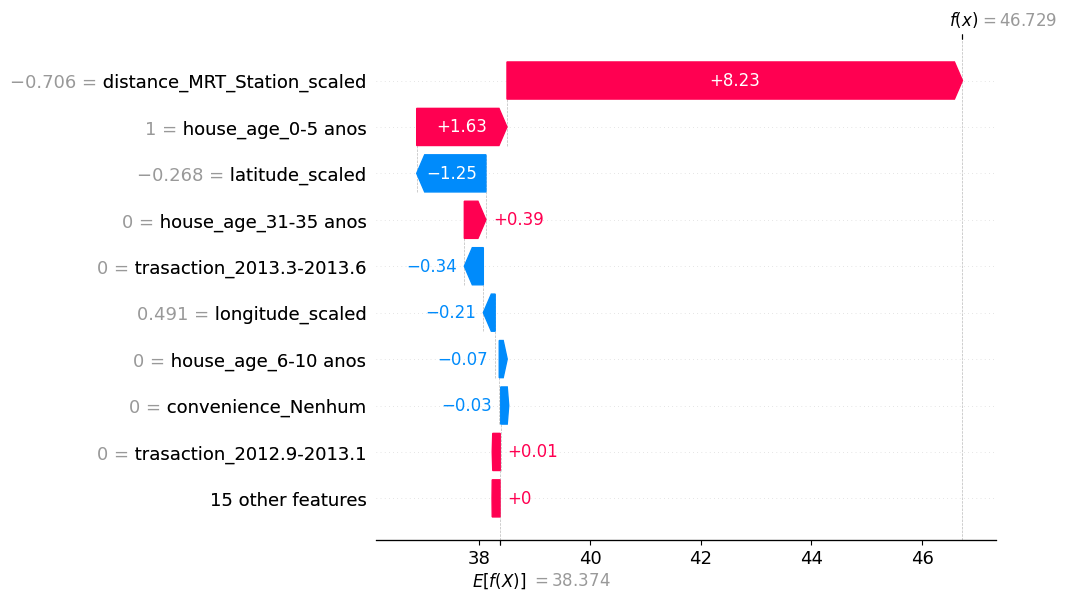

In [ ]:
#waterfall xgboost
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_xgb[0],
        base_values=explainer_xgb.expected_value,
        data=X_test_shap.iloc[0],
        feature_names=X.columns
    )
)

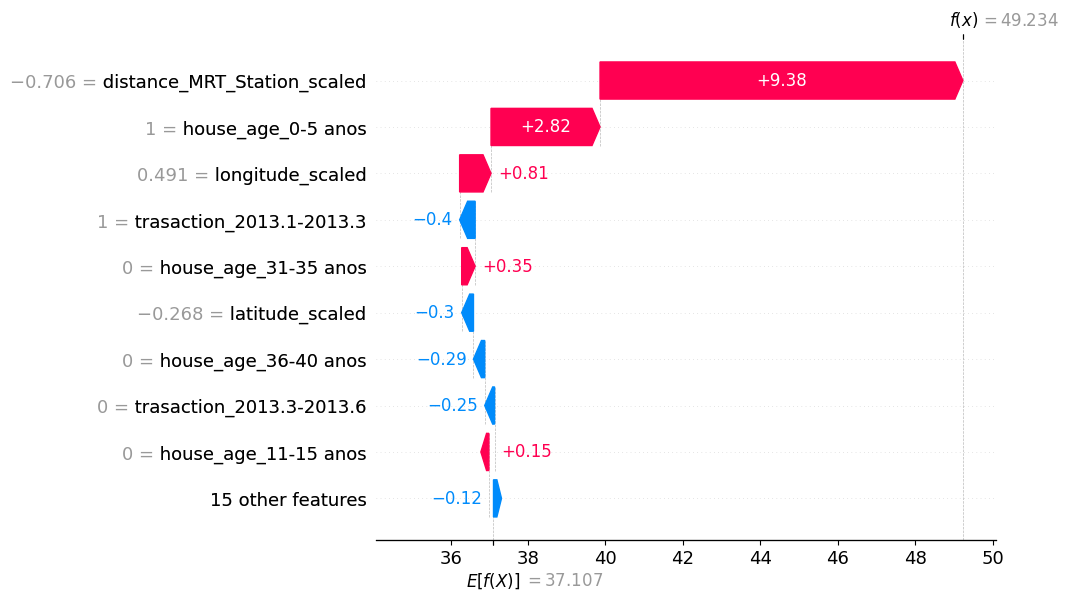

In [ ]:
#waterfall ramdom forest
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[0],
        feature_names=X.columns
    )
)
